# case a dt=0.05

In [7]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import time
import csv
import random
import warnings

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from scipy.optimize import fsolve, minimize

tf.config.set_visible_devices([], 'GPU')

#Config

TF64 = True

NX_COARSE = 11
NX_FINE   = 201

L  = 2*np.pi
DT = 0.05

USE_SIREN    = True
SIREN_W0     = 15.0
HIDDEN_UNITS = 512
DEPTH        = 5

# Training

EPOCHS = 2500

LR = 5e-5

SUP_WEIGHT  = 1.0

PHYS_WEIGHT = 0.1 / DT

BETA_L2   = 1e-6

GRAD_CLIP = 1.0

PATIENCE  = 800

# NEWTON
NEWTON_ALPHA = 0.5

# Outputs
OUT_DIR = "CaseD_Hybrid_Newton"

os.makedirs(OUT_DIR, exist_ok=True)

PLOTS_DIR = os.path.join(
    OUT_DIR,
    "plots"
)

os.makedirs(PLOTS_DIR, exist_ok=True)

WEIGHTS_FILE = os.path.join(
    OUT_DIR,
    "caseD_best.weights.h5"
)

META_FILE = os.path.join(
    OUT_DIR,
    "caseD_meta.npz"
)

DATA_FILE = os.path.join(
    OUT_DIR,
    "training_pairs.npz"
)

SUMMARY_FILE = os.path.join(
    OUT_DIR,
    "per_sample_summary_caseD.csv"
)

# Reproducibility
if TF64:
    tf.keras.backend.set_floatx("float64")

np.random.seed(42)

tf.random.set_seed(42)

random.seed(42)

warnings.filterwarnings("ignore")

# Differentiation matrix

def generate_D_matrix(Nx, L):

    k = 2*np.pi*1j*np.fft.fftfreq(
        Nx,
        d=L/Nx
    )

    I = np.eye(Nx)

    return np.fft.ifft(
        k[:,None] * np.fft.fft(I, axis=0),
        axis=0
    ).real

D_np = generate_D_matrix(NX_FINE, L)

D_tf = tf.constant(
    D_np,
    dtype=tf.float64
)

# Residuals
def residual_np(y, u):

    return y - u + 0.25 * DT * (D_np @ (y**2))

@tf.function
def residual_tf(y, u):

    y_sq = tf.square(y)

    dy_dx = tf.linalg.matmul(
        y_sq,
        tf.transpose(D_tf)
    )

    return y - u + 0.25 * DT * dy_dx

# Grids

x_coarse = np.linspace(
    0,
    L,
    NX_COARSE,
    endpoint=False
)

x_fine = np.linspace(
    0,
    L,
    NX_FINE,
    endpoint=False
)

# Fourier Interpolation
def fourier_interpolate(u, Nc, Nf):

    U = np.fft.fftshift(np.fft.fft(u))

    pad = Nf - Nc

    U = np.pad(
        U,
        (pad//2, pad-pad//2)
    )

    return (
        np.fft.ifft(np.fft.ifftshift(U))
        * Nf/Nc
    ).real

# fsolve

def compute_y1_fsolve(un):

    def F(y):

        return y - un + 0.25*DT*(D_np @ (y**2))

    def J(y):

        return (
            np.eye(len(un))
            + 0.5*DT*(D_np @ np.diag(y))
        )

    y, _, _, _ = fsolve(
        F,
        un,
        fprime=J,
        full_output=True
    )

    return y

# Training functions
def make_rich_family():

    fns = []
    
    for k in range(1, 13):
        fns.append((f"sin({k}x)", lambda x, kk=k: np.sin(kk*x)))
        fns.append((f"cos({k}x)", lambda x, kk=k: np.cos(kk*x)))

    # phase shifted
    for k in range(1, 6):
        for phi in [0.3, 0.7, 1.2]:
            fns.append((f"sin({k}x+{phi})",
                        lambda x, kk=k, pp=phi: np.sin(kk*x + pp)))

    # fractional freq
    for k in [1.5, 2.5, 3.5, 4.5]:
        fns.append((f"sin({k}x)", lambda x, kk=k: np.sin(kk*x)))
    # polynomial-type nonlinearities
    fns += [
        ("sin^2(x)"     , lambda x: np.sin(x)**2),
        ("cos^2(x)"     , lambda x: np.cos(x)**2),
        ("sin^3(x)"     , lambda x: np.sin(x)**3),
        ("cos^3(x)"     , lambda x: np.cos(x)**3),
    ]
    
    # mixed modes
    fns += [
        ("sin+0.5sin2", lambda x: np.sin(x)+0.5*np.sin(2*x)),
        ("cos+0.5cos2", lambda x: np.cos(x)+0.5*np.cos(2*x)),
        ("sin2+cos3"  , lambda x: np.sin(2*x)+np.cos(3*x)),
        ("sin3+cos5"  , lambda x: np.sin(3*x)+0.7*np.cos(5*x)),
        ("sin5+sin7"  , lambda x: 0.6*np.sin(5*x)+0.4*np.sin(7*x)),
        ("cos4+cos8"  , lambda x: 0.5*np.cos(4*x)+0.5*np.cos(8*x)),
    ]
    # Gaussians times sines/cosines
    fns += [
        ("gauss*sin(5x)",  lambda x: np.exp(-(x-np.pi)**2)*np.sin(5*x)),
        ("gauss*sin(10x)", lambda x: np.exp(-(x-np.pi)**2)*np.sin(10*x)),
        ("gauss*cos(7x)",  lambda x: np.exp(-0.5*(x-np.pi)**2)*np.cos(7*x)),
    ]
    # exponentials & combinations
    fns += [
        ("exp(-x)sin(x)",  lambda x: np.exp(-0.2*x)*np.sin(x)),
        ("exp(-x)cos(3x)", lambda x: np.exp(-0.4*x)*np.cos(3*x)),
    ]
    # random linear combos of sines/cosines
    rng = np.random.default_rng(123)
    for idx in range(30):   # ~30 random ICs
        ks  = rng.integers(1, 13, size=3)
        a   = rng.uniform(-1.0, 1.0, size=3)
        b   = rng.uniform(-1.0, 1.0, size=3)
        def make_fn(ks=ks, a=a, b=b):
            return lambda x, ks=ks, a=a, b=b: (
                a[0]*np.sin(ks[0]*x) + a[1]*np.cos(ks[1]*x) + a[2]*np.sin(ks[2]*x)
                + b[0]*np.cos(ks[0]*x) + b[1]*np.sin(ks[1]*x) + b[2]*np.cos(ks[2]*x)
            )
        fns.append((f"rand_combo_{idx}", make_fn()))
    return fns

train_fns = make_rich_family()

print(
    "Training family size:",
    len(train_fns)
)

# generate data
if os.path.exists(DATA_FILE):

    dd = np.load(DATA_FILE)

    un_train = dd["un"]

    y1_train = dd["y1"]

    print(
        "\nLoaded cached dataset:",
        un_train.shape
    )

else:

    print("\nGenerating training data...")

    U = []
    Y = []

    for i, (_, fn) in enumerate(train_fns):

        uc = fn(x_coarse)

        uf = fourier_interpolate(
            uc,
            NX_COARSE,
            NX_FINE
        )

        y1 = compute_y1_fsolve(uf)

        U.append(uf)

        Y.append(y1)

        print(
            f"{i+1}/{len(train_fns)}"
        )

    un_train = np.array(U)

    y1_train = np.array(Y)

    np.savez(
        DATA_FILE,
        un=un_train,
        y1=y1_train
    )

# features
def build_features(U):

    mag = np.abs(
        np.fft.fft(U, axis=-1)
    )[:, :NX_FINE//2+1]

    mag = 0.2 * mag

    return np.concatenate(
        [U, mag],
        axis=-1
    )

X_raw = build_features(un_train)

feat_mean = X_raw.mean(0)

feat_std = X_raw.std(0) + 1e-12

X_norm = (X_raw - feat_mean) / feat_std

print(
    "\nFeature shape:",
    X_norm.shape
)

# into tensors
X_tf = tf.constant(
    X_norm,
    dtype=tf.float64
)

U_tf = tf.constant(
    un_train,
    dtype=tf.float64
)

Y_tf = tf.constant(
    y1_train,
    dtype=tf.float64
)

# siren layers
class SineDense(tf.keras.layers.Layer):

    def __init__(
        self,
        units,
        w0=30,
        is_first=False
    ):

        super().__init__(dtype=tf.float64)

        self.units = units

        self.w0 = w0

        self.is_first = is_first

    def build(self, shape):

        d = int(shape[-1])

        bound = (
            (1/d)
            if self.is_first
            else
            np.sqrt(6/d)/self.w0
        )

        self.W = self.add_weight(
            shape=(d,self.units),
            initializer=tf.random_uniform_initializer(
                -bound,
                bound
            ),
            dtype=tf.float64
        )

        self.b = self.add_weight(
            shape=(self.units,),
            initializer="zeros",
            dtype=tf.float64
        )

    def call(self, x):

        return tf.sin(
            self.w0 * (
                x @ self.W + self.b
            )
        )

# model
def build_model():

    i = tf.keras.Input(
        shape=(X_norm.shape[1],),
        dtype=tf.float64
    )

    h = SineDense(
        HIDDEN_UNITS,
        SIREN_W0,
        True
    )(i)

    for _ in range(DEPTH-1):

        h = SineDense(
            HIDDEN_UNITS,
            SIREN_W0
        )(h)

    o = tf.keras.layers.Dense(
        NX_FINE,
        dtype=tf.float64
    )(h)

    return tf.keras.Model(i, o)

model = build_model()

_ = model(
    tf.zeros(
        (1, X_norm.shape[1]),
        dtype=tf.float64
    )
)

print(
    model.count_params(),
    "parameters"
)

# optimizer
opt = tf.keras.optimizers.Adam(LR)

# training
print("\nTRAINING CASE D")

best = np.inf

wait = 0

train_start = time.perf_counter()

for ep in range(1, EPOCHS+1):

    with tf.GradientTape() as tape:

        y = model(
            X_tf,
            training=True
        )

        sup = tf.reduce_mean(
            tf.square(y - Y_tf)
        )

        r = residual_tf(
            y,
            U_tf
        )

        phys = tf.reduce_mean(
            tf.square(r)
        )

        reg = BETA_L2 * tf.add_n([

            tf.nn.l2_loss(v)

            for v in model.trainable_variables
        ])

        total = (

            SUP_WEIGHT * sup

            + PHYS_WEIGHT * phys

            + reg
        )

    grads = tape.gradient(
        total,
        model.trainable_variables
    )

    grads = [

        tf.clip_by_norm(g, GRAD_CLIP)

        for g in grads
    ]

    opt.apply_gradients(
        zip(grads, model.trainable_variables)
    )

    if ep % 100 == 0 or ep == 1:

        print(
            f"Epoch {ep:4d} | "
            f"Total={float(total):.3e} | "
            f"Sup={float(sup):.3e} | "
            f"Phys={float(phys):.3e}"
        )

    total_val = float(total)

    if total_val < best:

        best = total_val

        wait = 0

        model.save_weights(
            WEIGHTS_FILE
        )

    else:

        wait += 1

        if wait > PATIENCE:

            print("Early stopping.")

            break

train_end = time.perf_counter()

print("\nTRAINING COMPLETE")

print(
    "Training time: %.2f sec"
    % (train_end-train_start)
)

# saving meta
np.savez(

    META_FILE,

    feat_mean=feat_mean,

    feat_std=feat_std,

    NX_FINE=NX_FINE,

    NX_COARSE=NX_COARSE,

    DT=DT,

    L=L
)

print("\nSaved weights:", WEIGHTS_FILE)

print("Saved meta:", META_FILE)


Training family size: 88

Generating training data...
1/88
2/88
3/88
4/88
5/88
6/88
7/88
8/88
9/88
10/88
11/88
12/88
13/88
14/88
15/88
16/88
17/88
18/88
19/88
20/88
21/88
22/88
23/88
24/88
25/88
26/88
27/88
28/88
29/88
30/88
31/88
32/88
33/88
34/88
35/88
36/88
37/88
38/88
39/88
40/88
41/88
42/88
43/88
44/88
45/88
46/88
47/88
48/88
49/88
50/88
51/88
52/88
53/88
54/88
55/88
56/88
57/88
58/88
59/88
60/88
61/88
62/88
63/88
64/88
65/88
66/88
67/88
68/88
69/88
70/88
71/88
72/88
73/88
74/88
75/88
76/88
77/88
78/88
79/88
80/88
81/88
82/88
83/88
84/88
85/88
86/88
87/88
88/88

Feature shape: (88, 302)
1308873 parameters

TRAINING CASE D
Epoch    1 | Total=3.920e+00 | Sup=1.130e+00 | Phys=1.395e+00
Epoch  100 | Total=2.538e-02 | Sup=6.854e-03 | Phys=9.187e-03
Epoch  200 | Total=8.778e-03 | Sup=1.992e-03 | Phys=3.316e-03
Epoch  300 | Total=6.052e-03 | Sup=1.108e-03 | Phys=2.395e-03
Epoch  400 | Total=4.770e-03 | Sup=9.358e-04 | Phys=1.840e-03
Epoch  500 | Total=2.822e-03 | Sup=5.072e-04 | Phys=1.0

# Computational metrics

In [10]:
import os
import csv
import time
import psutil

import numpy as np
import tensorflow as tf

from scipy.optimize import fsolve

tf.config.set_visible_devices([], 'GPU')

# CONFIG

NEWTON_ALPHA = 0.5

# Paths

OUT_DIR = "CaseD_Hybrid_Newton"

WEIGHTS_FILE = os.path.join(
    OUT_DIR,
    "caseD_best.weights.h5"
)

META_FILE = os.path.join(
    OUT_DIR,
    "caseD_meta.npz"
)

METRICS_FILE = os.path.join(
    OUT_DIR,
    "computational_metrics.csv"
)

# Memory
process = psutil.Process(os.getpid())

def memory_mb():

    return process.memory_info().rss / 1024**2

# Load meta
meta = np.load(META_FILE, allow_pickle=True)

NX_FINE   = int(meta["NX_FINE"])
NX_COARSE = int(meta["NX_COARSE"])

DT = float(meta["DT"])
L  = float(meta["L"])

feat_mean = meta["feat_mean"]
feat_std  = meta["feat_std"]

# architecture
HIDDEN_UNITS = 512
DEPTH        = 5
SIREN_W0     = 15.0

# grids
x_coarse = np.linspace(
    0,
    L,
    NX_COARSE,
    endpoint=False
)

x_fine = np.linspace(
    0,
    L,
    NX_FINE,
    endpoint=False
)

# differentiation matrix
def generate_D_matrix(Nx, L):

    k = 2*np.pi*1j*np.fft.fftfreq(
        Nx,
        d=L/Nx
    )

    I = np.eye(Nx)

    return np.fft.ifft(
        k[:, None] * np.fft.fft(I, axis=0),
        axis=0
    ).real

D_np = generate_D_matrix(NX_FINE, L)

# residual
def residual_np(y, u):

    return y - u + 0.25 * DT * (D_np @ (y**2))

# fsolve
def compute_y1_fsolve(un):

    def F(y):

        return y - un + 0.25 * DT * (D_np @ (y**2))

    def J(y):

        return (
            np.eye(len(un))
            + 0.5 * DT * (D_np @ np.diag(y))
        )

    y = fsolve(
        F,
        un,
        fprime=J,
        xtol=1e-12
    )

    return y.astype(np.float64)

# fourier interpolation
def fourier_interpolate(u, Nc, Nf):

    U = np.fft.fftshift(np.fft.fft(u))

    pad = Nf - Nc

    U = np.pad(
        U,
        (pad//2, pad-pad//2)
    )

    return (
        np.fft.ifft(np.fft.ifftshift(U))
        * Nf/Nc
    ).real

# features
def build_feat_single(u_f):

    mag = np.abs(
        np.fft.fft(u_f)
    )[:NX_FINE//2+1]

    mag = 0.2 * mag

    feats = np.concatenate([u_f, mag])

    return (
        (feats - feat_mean) / feat_std
    )[None, :]

# newton correctior
def newton_correct(y, u):

    r = residual_np(y, u)

    J = (
        np.eye(NX_FINE)
        + 0.5 * DT * (
            D_np @ np.diag(y)
        )
    )

    delta = np.linalg.solve(J, r)

    return y - NEWTON_ALPHA * delta

# siren layer
class SineDense(tf.keras.layers.Layer):

    def __init__(
        self,
        units,
        w0=30,
        is_first=False
    ):

        super().__init__(dtype=tf.float64)

        self.units = units
        self.w0 = w0
        self.is_first = is_first

    def build(self, shape):

        d = int(shape[-1])

        bound = (
            (1/d)
            if self.is_first
            else
            np.sqrt(6/d)/self.w0
        )

        self.W = self.add_weight(
            shape=(d, self.units),
            initializer=tf.random_uniform_initializer(
                -bound,
                bound
            ),
            dtype=tf.float64
        )

        self.b = self.add_weight(
            shape=(self.units,),
            initializer="zeros",
            dtype=tf.float64
        )

    def call(self, x):

        return tf.sin(
            self.w0 * (
                x @ self.W + self.b
            )
        )

# model
def build_model():

    i = tf.keras.Input(
        shape=(len(feat_mean),),
        dtype=tf.float64
    )

    h = SineDense(
        HIDDEN_UNITS,
        SIREN_W0,
        True
    )(i)

    for _ in range(DEPTH-1):

        h = SineDense(
            HIDDEN_UNITS,
            SIREN_W0
        )(h)

    o = tf.keras.layers.Dense(
        NX_FINE,
        dtype=tf.float64
    )(h)

    return tf.keras.Model(i, o)

# load model
model = build_model()

_ = model(
    tf.zeros((1, len(feat_mean)), dtype=tf.float64)
)

model.load_weights(WEIGHTS_FILE)

print("\nLoaded saved model.")

# testing functions
tests = [
    (
        "sin(x)",
        lambda x: np.sin(x)
    ),
    
    (
        "0.5+0.25sin(x)",
        lambda x: 0.5 + 0.25*np.sin(x)
    ), 
    # Irrational-frequency sin/cos
    (
        "sin(sqrt(2)x)",
        lambda x: np.sin(np.sqrt(2)*x)
    ),

    (
        "cos(sqrt(3)x)",
        lambda x: np.cos(np.sqrt(3)*x)
    ),   
    # Gaussian + irrational frequency
    (
        "exp(-(x-pi)^2)*sin(sqrt(2)x)",
        lambda x: np.exp(-(x - np.pi)**2)
                  * np.sin(np.sqrt(2)*x)
    ),      
    # Normalised polynomial family
    (
        "((x-pi)^2)/(pi^2)",
        lambda x: ((x - np.pi)**2) / (np.pi**2)
    ),

    (
        "(pi^2-(x-pi)^2)/(pi^2)",
        lambda x: (np.pi**2 - (x - np.pi)**2) / (np.pi**2)
    )
    
]
# metrics
rows = []

for name, fn in tests:

    print("\n====================")
    print(name)

    uf = fourier_interpolate(
        fn(x_coarse),
        NX_COARSE,
        NX_FINE
    )

    feat = build_feat_single(uf)

    # RAW NN TIMING
    t0 = time.perf_counter()

    y_raw = model(
        tf.constant(feat, dtype=tf.float64),
        training=False
    ).numpy()[0]

    t1 = time.perf_counter()

    raw_nn_ms = 1000 * (t1 - t0)

    # Newton correction timing
    n0 = time.perf_counter()

    y_corr = newton_correct(y_raw, uf)

    n1 = time.perf_counter()

    newton_ms = 1000 * (n1 - n0)

    # total hybrid
    total_hybrid_ms = raw_nn_ms + newton_ms
    
    # Fsolve
    fs0 = time.perf_counter()

    y_fs = compute_y1_fsolve(uf)

    fs1 = time.perf_counter()

    fsolve_ms = 1000 * (fs1 - fs0)

    # Raw residual
    r_raw = residual_np(y_raw, uf)

    raw_Linf = np.max(np.abs(r_raw))

    raw_mean = np.mean(np.abs(r_raw))

    # corrected residual
    r_corr = residual_np(y_corr, uf)

    corr_Linf = np.max(np.abs(r_corr))

    corr_mean = np.mean(np.abs(r_corr))

    mem_now = memory_mb()

    # Print
    print(f"Raw NN time      : {raw_nn_ms:.3f} ms")

    print(f"Newton corr time : {newton_ms:.3f} ms")

    print(f"Total hybrid     : {total_hybrid_ms:.3f} ms")

    print(f"fsolve solve     : {fsolve_ms:.3f} ms")

    print(f"Raw Linf         : {raw_Linf:.3e}")

    print(f"Corrected Linf   : {corr_Linf:.3e}")

    print(f"Memory usage     : {mem_now:.2f} MB")
    
    # Save row
    rows.append([

        name,

        raw_nn_ms,

        newton_ms,

        total_hybrid_ms,

        fsolve_ms,

        mem_now,

        raw_Linf,

        raw_mean,

        corr_Linf,

        corr_mean
    ])

# Save csv
with open(METRICS_FILE, "w", newline="") as f:

    writer = csv.writer(f)

    writer.writerow([

        "Function",

        "Raw_NN_ms",

        "Newton_ms",

        "Total_Hybrid_ms",

        "fsolve_ms",

        "Memory_MB",

        "Raw_Linf",

        "Raw_MeanResidual",

        "Corrected_Linf",

        "Corrected_MeanResidual"
    ])

    writer.writerows(rows)

print("\nSaved metrics CSV:")

print(METRICS_FILE)


Loaded saved model.

sin(x)
Raw NN time      : 13.613 ms
Newton corr time : 71.584 ms
Total hybrid     : 85.196 ms
fsolve solve     : 42.357 ms
Raw Linf         : 7.799e-02
Corrected Linf   : 3.910e-02
Memory usage     : 378.33 MB

0.5+0.25sin(x)
Raw NN time      : 10.275 ms
Newton corr time : 75.958 ms
Total hybrid     : 86.233 ms
fsolve solve     : 35.317 ms
Raw Linf         : 4.231e-01
Corrected Linf   : 2.171e-01
Memory usage     : 378.33 MB

sin(sqrt(2)x)
Raw NN time      : 13.815 ms
Newton corr time : 77.205 ms
Total hybrid     : 91.020 ms
fsolve solve     : 18.247 ms
Raw Linf         : 2.563e-01
Corrected Linf   : 1.282e-01
Memory usage     : 378.33 MB

cos(sqrt(3)x)
Raw NN time      : 15.801 ms
Newton corr time : 56.475 ms
Total hybrid     : 72.276 ms
fsolve solve     : 47.216 ms
Raw Linf         : 4.780e-01
Corrected Linf   : 2.370e-01
Memory usage     : 378.33 MB

exp(-(x-pi)^2)*sin(sqrt(2)x)
Raw NN time      : 12.188 ms
Newton corr time : 68.486 ms
Total hybrid     : 80.675

# testing code



Loaded saved model.

TEST & DIAGNOSTICS

--- sin(x) ---
[test] sin(x)       | L∞=8.322e-04 | Mean=1.087e-04
NN inference : 73.829 ms
fsolve solve : 30.411 ms
5-step rollout: 0.299 sec
Memory usage : 403.66 MB


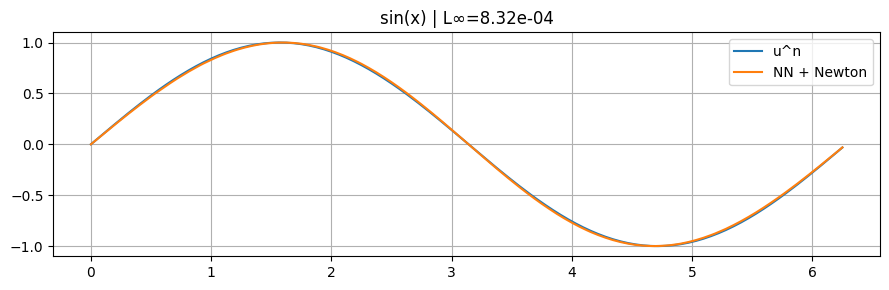

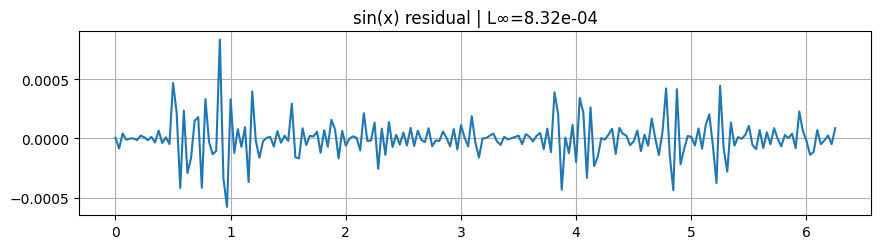

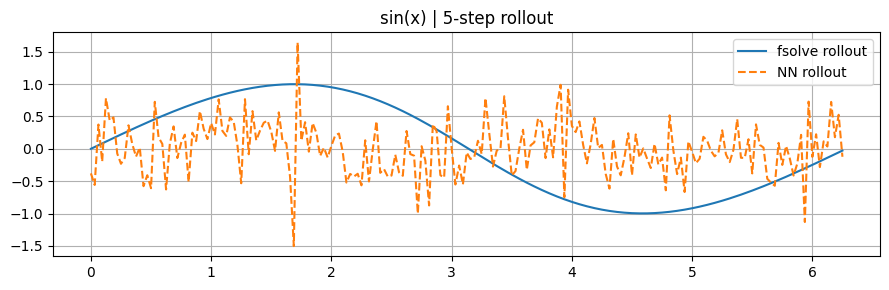


--- 0.5+0.25sin(x) ---
[test] 0.5+0.25sin(x) | L∞=4.525e-02 | Mean=9.565e-03
NN inference : 60.347 ms
fsolve solve : 21.080 ms
5-step rollout: 0.300 sec
Memory usage : 411.96 MB


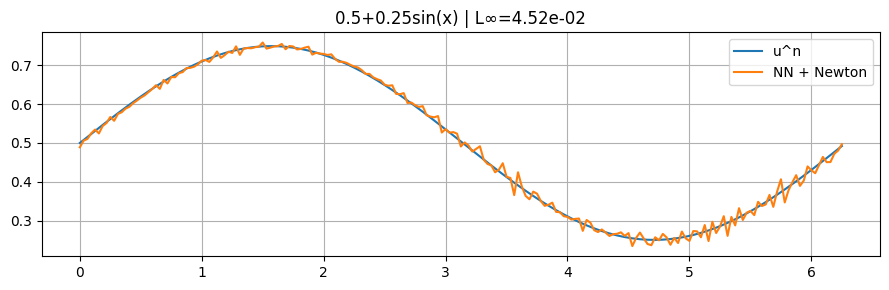

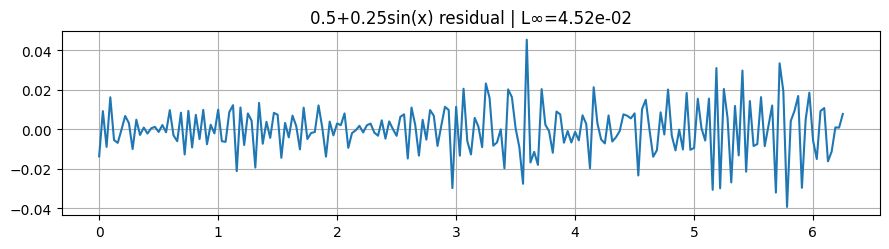

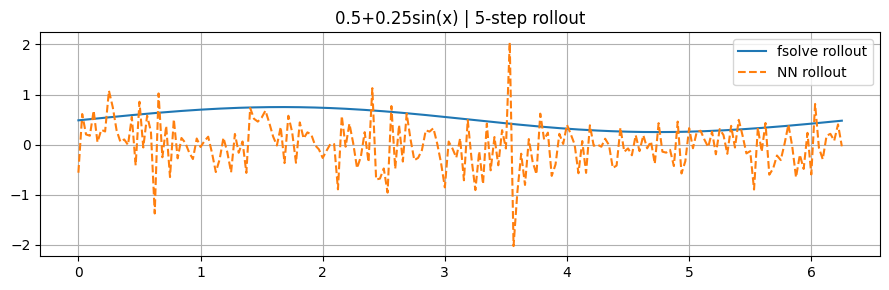


--- sin(sqrt(2)x) ---
[test] sin(sqrt(2)x) | L∞=2.414e-02 | Mean=3.122e-03
NN inference : 65.573 ms
fsolve solve : 22.588 ms
5-step rollout: 0.277 sec
Memory usage : 414.01 MB


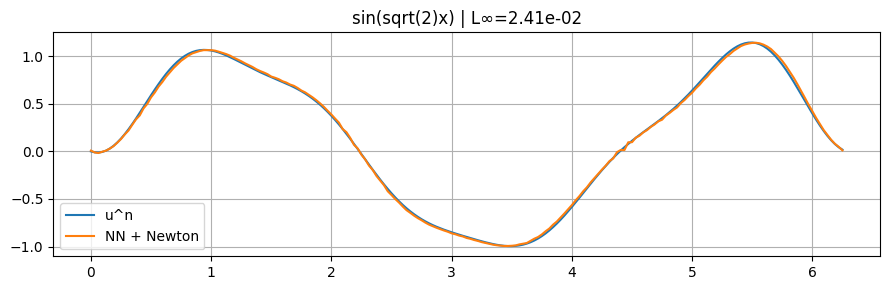

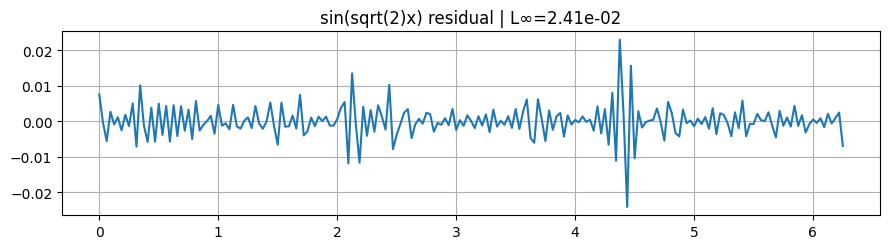

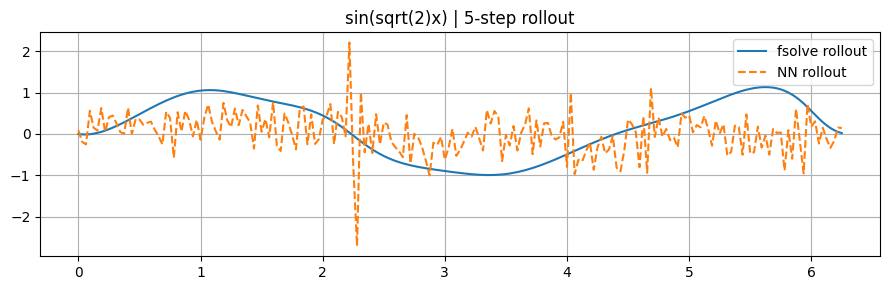


--- cos(sqrt(3)x) ---
[test] cos(sqrt(3)x) | L∞=1.057e-01 | Mean=1.407e-02
NN inference : 66.691 ms
fsolve solve : 29.668 ms
5-step rollout: 0.318 sec
Memory usage : 417.93 MB


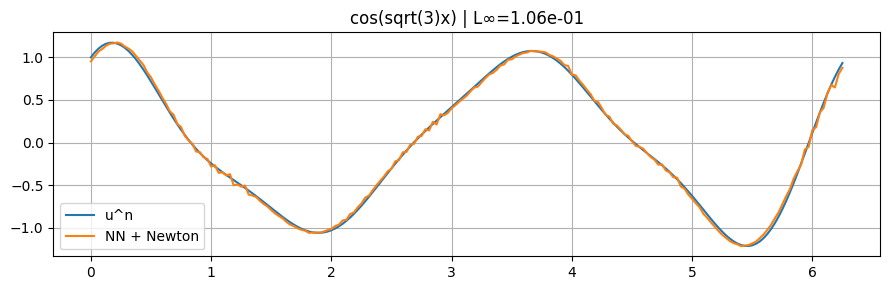

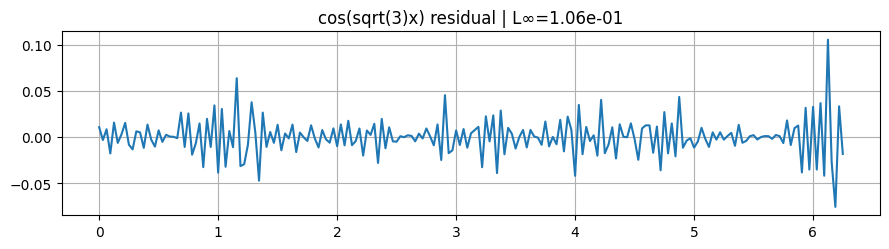

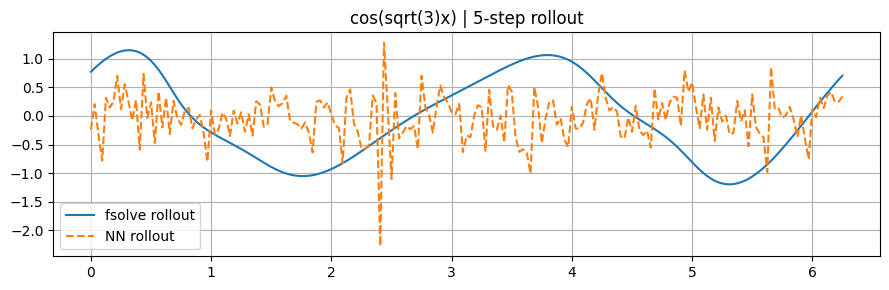


--- exp(-(x-pi)^2)*sin(sqrt(2)x) ---
[test] exp(-(x-pi)^2)*sin(sqrt(2)x) | L∞=1.158e-01 | Mean=2.232e-02
NN inference : 82.503 ms
fsolve solve : 21.603 ms
5-step rollout: 0.277 sec
Memory usage : 415.89 MB


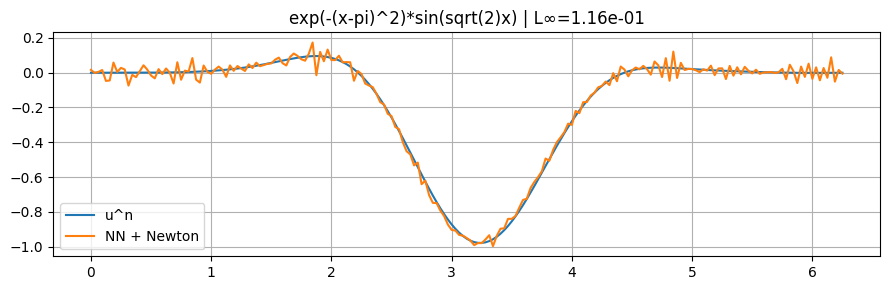

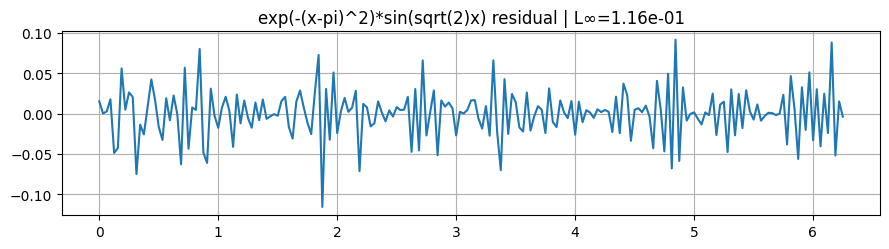

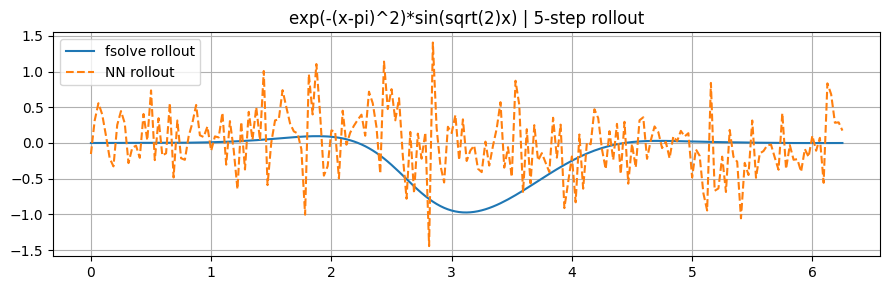


--- ((x-pi)^2)/(pi^2) ---
[test] ((x-pi)^2)/(pi^2) | L∞=4.266e-02 | Mean=8.076e-03
NN inference : 64.324 ms
fsolve solve : 22.278 ms
5-step rollout: 0.333 sec
Memory usage : 415.90 MB


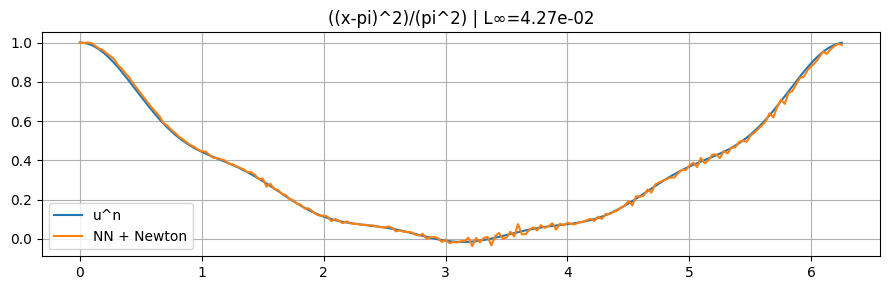

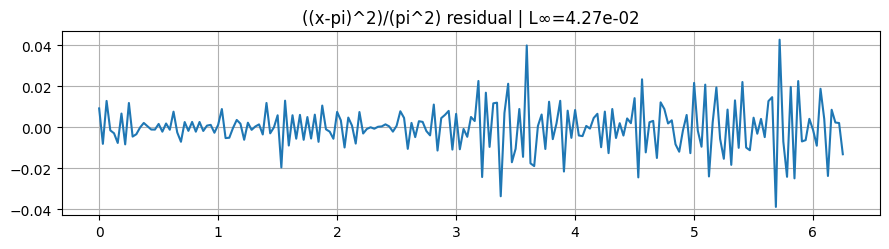

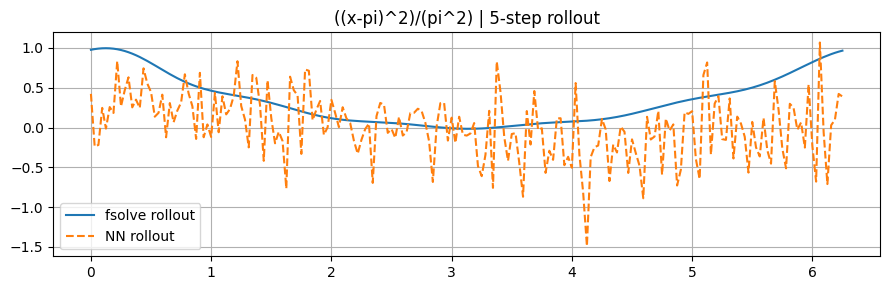


--- (pi^2-(x-pi)^2)/(pi^2) ---
[test] (pi^2-(x-pi)^2)/(pi^2) | L∞=8.389e-02 | Mean=1.651e-02
NN inference : 65.443 ms
fsolve solve : 22.436 ms
5-step rollout: 0.308 sec
Memory usage : 419.29 MB


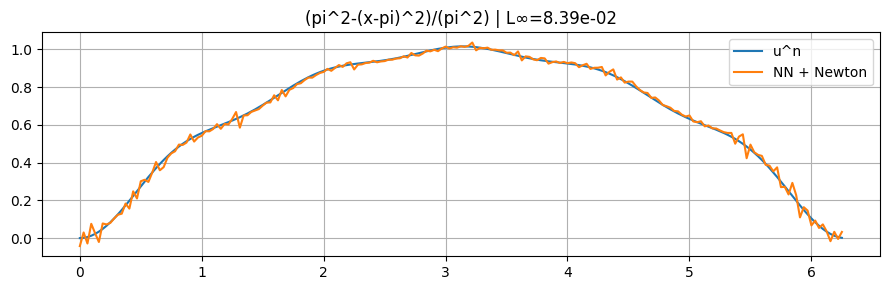

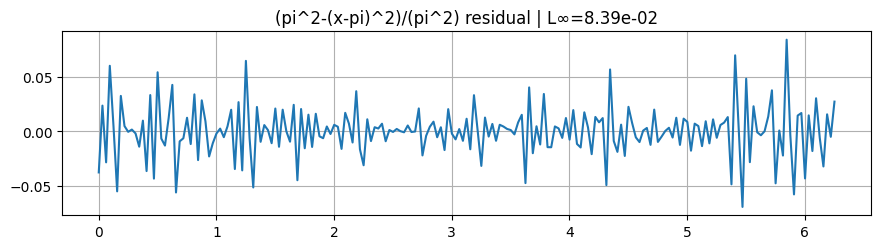

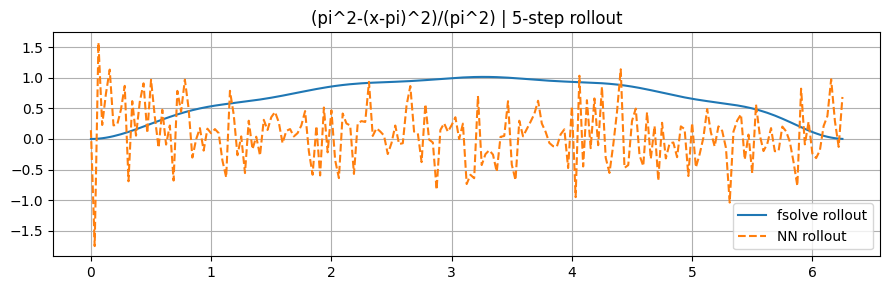


Saved summary CSV:
CaseD_Hybrid_Newton\testing_summary_caseD.csv

Plots saved in:
CaseD_Hybrid_Newton\plots

DONE.


In [5]:

import os
import csv
import time
import psutil

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from scipy.optimize import fsolve

tf.config.set_visible_devices([], 'GPU')

# paths
OUT_DIR = "CaseD_Hybrid_Newton"

PLOTS_DIR = os.path.join(
    OUT_DIR,
    "plots"
)

os.makedirs(PLOTS_DIR, exist_ok=True)

WEIGHTS_FILE = os.path.join(
    OUT_DIR,
    "caseD_best.weights.h5"
)

META_FILE = os.path.join(
    OUT_DIR,
    "caseD_meta.npz"
)

CSV_FILE = os.path.join(
    OUT_DIR,
    "testing_summary_caseD.csv"
)

# memory
process = psutil.Process(os.getpid())

def memory_mb():

    return process.memory_info().rss / 1024**2

# load meta
meta = np.load(
    META_FILE,
    allow_pickle=True
)

NX_FINE   = int(meta["NX_FINE"])

NX_COARSE = int(meta["NX_COARSE"])

DT = float(meta["DT"])

L  = float(meta["L"])

feat_mean = meta["feat_mean"]

feat_std  = meta["feat_std"]

# model config
HIDDEN_UNITS = 512

DEPTH = 5

SIREN_W0 = 15.0

NEWTON_ALPHA = 0.5

# grids
x_coarse = np.linspace(
    0,
    L,
    NX_COARSE,
    endpoint=False
)

x_fine = np.linspace(
    0,
    L,
    NX_FINE,
    endpoint=False
)

# differentiation matrix
def generate_D_matrix(Nx, L):

    k = 2*np.pi*1j*np.fft.fftfreq(
        Nx,
        d=L/Nx
    )

    I = np.eye(Nx)

    D_fft = np.fft.ifft(
        k[:, None] * np.fft.fft(I, axis=0),
        axis=0
    )

    return D_fft.real

D_np = generate_D_matrix(
    NX_FINE,
    L
)

# residual
def residual_np(y, u):

    return (
        y
        - u
        + 0.25*DT*(D_np @ (y**2))
    )

# fourier interpolation
def fourier_interpolate(u, Nc, Nf):

    U = np.fft.fftshift(
        np.fft.fft(u)
    )

    pad = Nf - Nc

    U = np.pad(
        U,
        (pad//2, pad-pad//2)
    )

    return (
        np.fft.ifft(
            np.fft.ifftshift(U)
        ) * Nf/Nc
    ).real

# fsolve
def compute_y1_fsolve(un):

    def F(y):

        return (
            y
            - un
            + 0.25*DT*(D_np @ (y**2))
        )

    def J(y):

        return (
            np.eye(len(un))
            + 0.5*DT*(D_np @ np.diag(y))
        )

    y = fsolve(
        F,
        un,
        fprime=J,
        xtol=1e-12
    )

    return y.astype(np.float64)

# newton corrector
def newton_correct(y, u):

    r = residual_np(y, u)

    J = (
        np.eye(NX_FINE)
        + 0.5 * DT * (
            D_np @ np.diag(y)
        )
    )

    try:

        delta = np.linalg.solve(J, r)

    except np.linalg.LinAlgError:

        delta = np.linalg.lstsq(
            J,
            r,
            rcond=None
        )[0]

    return y - delta

# Siren layer
class SineDense(tf.keras.layers.Layer):

    def __init__(
        self,
        units,
        w0=30.0,
        is_first=False,
        **kwargs
    ):

        super().__init__(
            dtype=tf.float64,
            **kwargs
        )

        self.units = int(units)

        self.w0 = float(w0)

        self.is_first = bool(is_first)

    def build(self, input_shape):

        in_dim = int(input_shape[-1])

        bound = (
            (1.0/in_dim)
            if self.is_first
            else
            (np.sqrt(6.0/in_dim)/self.w0)
        )

        self.W = self.add_weight(
            shape=(in_dim, self.units),
            initializer=tf.keras.initializers.RandomUniform(
                -bound,
                bound
            ),
            trainable=True,
            dtype=tf.float64
        )

        self.b = self.add_weight(
            shape=(self.units,),
            initializer="zeros",
            trainable=True,
            dtype=tf.float64
        )

    def call(self, x):

        return tf.sin(
            self.w0 * (
                tf.matmul(x, self.W) + self.b
            )
        )

# model
def build_model():

    input_dim = len(feat_mean)

    inputs = tf.keras.Input(
        shape=(input_dim,),
        dtype=tf.float64
    )

    h = inputs

    h = SineDense(
        HIDDEN_UNITS,
        w0=SIREN_W0,
        is_first=True
    )(h)

    for _ in range(DEPTH-1):

        h = SineDense(
            HIDDEN_UNITS,
            w0=SIREN_W0
        )(h)

    outputs = tf.keras.layers.Dense(
        NX_FINE,
        dtype=tf.float64
    )(h)

    return tf.keras.Model(
        inputs,
        outputs
    )

# model
model = build_model()

_ = model(
    tf.zeros(
        (1, len(feat_mean)),
        dtype=tf.float64
    )
)

model.load_weights(
    WEIGHTS_FILE
)

print("\nLoaded saved model.")

# safe filename
def safe_filename(name):

    return (
        name.replace("(", "")
            .replace(")", "")
            .replace("*", "")
            .replace("^", "")
            .replace("+", "")
            .replace("-", "")
            .replace("/", "_")
            .replace("\\", "_")
            .replace("=", "_")
            .replace(" ", "_")
    )

# features
def build_feat_single(u_f):

    mag = np.abs(
        np.fft.fft(u_f)
    )[:NX_FINE//2+1]

    mag = 0.2 * mag

    feats = np.concatenate([
        u_f,
        mag
    ])

    return (
        (feats - feat_mean)
        / feat_std
    )[None, :]

# rollout
def rollout_nn(u0, steps=5):

    u = u0.copy()

    traj = [u.copy()]

    for _ in range(steps):

        feat = build_feat_single(u)

        y = model(
            tf.constant(
                feat,
                dtype=tf.float64
            ),
            training=False
        ).numpy()[0]

        y_new = newton_correct(y, u)

        y = (
            (1 - NEWTON_ALPHA) * y
            + NEWTON_ALPHA * y_new
        )

        u = y.copy()

        traj.append(u.copy())

    return traj

# Test function
tests = [
    (
        "sin(x)",
        lambda x: np.sin(x)
    ),
    
    (
        "0.5+0.25sin(x)",
        lambda x: 0.5 + 0.25*np.sin(x)
    ), 
    # Irrational-frequency sin/cos
    (
        "sin(sqrt(2)x)",
        lambda x: np.sin(np.sqrt(2)*x)
    ),

    (
        "cos(sqrt(3)x)",
        lambda x: np.cos(np.sqrt(3)*x)
    ),   
    # Gaussian + irrational frequency
    (
        "exp(-(x-pi)^2)*sin(sqrt(2)x)",
        lambda x: np.exp(-(x - np.pi)**2)
                  * np.sin(np.sqrt(2)*x)
    ),      
    # Normalised polynomial family
    (
        "((x-pi)^2)/(pi^2)",
        lambda x: ((x - np.pi)**2) / (np.pi**2)
    ),

    (
        "(pi^2-(x-pi)^2)/(pi^2)",
        lambda x: (np.pi**2 - (x - np.pi)**2) / (np.pi**2)
    )
    
]

summary = []

# Testing
print("\nTEST & DIAGNOSTICS")

for name, fn in tests:

    print("\n---", name, "---")

    safe_name = safe_filename(name)

    # Initial condition
    uf = fourier_interpolate(
        fn(x_coarse),
        NX_COARSE,
        NX_FINE
    )

    # NN prediction
    feat = build_feat_single(uf)

    t0 = time.perf_counter()

    y_pred = model(
        tf.constant(
            feat,
            dtype=tf.float64
        ),
        training=False
    ).numpy()[0]

    # Newton corrector
    y_pred = newton_correct(
        y_pred,
        uf
    )

    t1 = time.perf_counter()

    nn_ms = 1000 * (t1 - t0)

    # Fsolve
    fs0 = time.perf_counter()

    y_fs = compute_y1_fsolve(uf)

    fs1 = time.perf_counter()

    fsolve_ms = 1000 * (fs1 - fs0)

    # Residual
    r = residual_np(
        y_pred,
        uf
    )

    Linf = float(
        np.max(np.abs(r))
    )

    Mean = float(
        np.mean(np.abs(r))
    )

    # Rollout
    steps = 5

    r0 = time.perf_counter()

    traj_nn = rollout_nn(
        uf,
        steps
    )

    r1 = time.perf_counter()

    rollout_sec = r1 - r0

    # Fsolve rollout
    traj_fs = [uf.copy()]

    tmp = uf.copy()

    for _ in range(steps):

        tmp = compute_y1_fsolve(tmp)

        traj_fs.append(tmp.copy())

    mem_now = memory_mb()

    print(
        f"[test] {name:12s} | "
        f"L∞={Linf:.3e} | "
        f"Mean={Mean:.3e}"
    )

    print(f"NN inference : {nn_ms:.3f} ms")

    print(f"fsolve solve : {fsolve_ms:.3f} ms")

    print(f"5-step rollout: {rollout_sec:.3f} sec")

    print(f"Memory usage : {mem_now:.2f} MB")

    xs = x_fine

    # Sol plot
    plt.figure(figsize=(9,3))

    plt.plot(
        xs,
        uf,
        label="u^n"
    )

    plt.plot(
        xs,
        y_pred,
        label="NN + Newton"
    )


    plt.legend()

    plt.title(
        f"{name} | L∞={Linf:.2e}"
    )

    plt.grid(True)

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            PLOTS_DIR,
            f"{safe_name}_nn.png"
        ),
        dpi=150
    )

    plt.show()
    # Residual plot
    plt.figure(figsize=(9,2.6))

    plt.plot(xs, r)

    plt.title(
        f"{name} residual | L∞={Linf:.2e}"
    )

    plt.grid(True)

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            PLOTS_DIR,
            f"{safe_name}_res.png"
        ),
        dpi=150
    )

    plt.show()

    # Rollout
    plt.figure(figsize=(9,3))

    plt.plot(
        xs,
        traj_fs[-1],
        label="fsolve rollout"
    )

    plt.plot(
        xs,
        traj_nn[-1],
        "--",
        label="NN rollout"
    )

    plt.legend()

    plt.title(
        f"{name} | {steps}-step rollout"
    )

    plt.grid(True)

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            PLOTS_DIR,
            f"{safe_name}_rollout.png"
        ),
        dpi=150
    )

    plt.show()

    summary.append([

        name,

        Linf,

        Mean,

        nn_ms,

        fsolve_ms,

        rollout_sec,

        mem_now
    ])

# SAVE CSV
with open(CSV_FILE, "w", newline="") as f:

    writer = csv.writer(f)

    writer.writerow([

        "Function",

        "Linf",

        "MeanResidual",

        "NN_Inference_ms",

        "fsolve_ms",

        "Rollout_sec",

        "Memory_MB"
    ])

    writer.writerows(summary)

print("\nSaved summary CSV:")

print(CSV_FILE)

print("\nPlots saved in:")

print(PLOTS_DIR)

print("\nDONE."

# Case 2 for dt=0.005

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import time
import csv
import random
import warnings

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from scipy.optimize import fsolve, minimize

tf.config.set_visible_devices([], 'GPU')

#Config

TF64 = True

NX_COARSE = 11
NX_FINE   = 201

L  = 2*np.pi
DT = 0.005

USE_SIREN    = True
SIREN_W0     = 15.0
HIDDEN_UNITS = 512
DEPTH        = 5

# Training

EPOCHS = 2500

LR = 5e-5

SUP_WEIGHT  = 1.0

PHYS_WEIGHT = 0.1 / DT

BETA_L2   = 1e-6

GRAD_CLIP = 1.0

PATIENCE  = 800

# NEWTON
NEWTON_ALPHA = 0.5

# Outputs
OUT_DIR = "CaseD_Hybrid_Newton_0.005"

os.makedirs(OUT_DIR, exist_ok=True)

PLOTS_DIR = os.path.join(
    OUT_DIR,
    "plots"
)

os.makedirs(PLOTS_DIR, exist_ok=True)

WEIGHTS_FILE = os.path.join(
    OUT_DIR,
    "caseD_best_0.005.weights.h5"
)

META_FILE = os.path.join(
    OUT_DIR,
    "caseD_meta_0.005.npz"
)

DATA_FILE = os.path.join(
    OUT_DIR,
    "training_pairs_0.005.npz"
)

SUMMARY_FILE = os.path.join(
    OUT_DIR,
    "per_sample_summary_caseD_0,005.csv"
)

# Reproducibility
if TF64:
    tf.keras.backend.set_floatx("float64")

np.random.seed(42)

tf.random.set_seed(42)

random.seed(42)

warnings.filterwarnings("ignore")

# Differentiation matrix

def generate_D_matrix(Nx, L):

    k = 2*np.pi*1j*np.fft.fftfreq(
        Nx,
        d=L/Nx
    )

    I = np.eye(Nx)

    return np.fft.ifft(
        k[:,None] * np.fft.fft(I, axis=0),
        axis=0
    ).real

D_np = generate_D_matrix(NX_FINE, L)

D_tf = tf.constant(
    D_np,
    dtype=tf.float64
)

# Residuals
def residual_np(y, u):

    return y - u + 0.25 * DT * (D_np @ (y**2))

@tf.function
def residual_tf(y, u):

    y_sq = tf.square(y)

    dy_dx = tf.linalg.matmul(
        y_sq,
        tf.transpose(D_tf)
    )

    return y - u + 0.25 * DT * dy_dx

# Grids

x_coarse = np.linspace(
    0,
    L,
    NX_COARSE,
    endpoint=False
)

x_fine = np.linspace(
    0,
    L,
    NX_FINE,
    endpoint=False
)

# Fourier Interpolation
def fourier_interpolate(u, Nc, Nf):

    U = np.fft.fftshift(np.fft.fft(u))

    pad = Nf - Nc

    U = np.pad(
        U,
        (pad//2, pad-pad//2)
    )

    return (
        np.fft.ifft(np.fft.ifftshift(U))
        * Nf/Nc
    ).real

# fsolve

def compute_y1_fsolve(un):

    def F(y):

        return y - un + 0.25*DT*(D_np @ (y**2))

    def J(y):

        return (
            np.eye(len(un))
            + 0.5*DT*(D_np @ np.diag(y))
        )

    y, _, _, _ = fsolve(
        F,
        un,
        fprime=J,
        full_output=True
    )

    return y

# Training functions
def make_rich_family():

    fns = []
    
    for k in range(1, 13):
        fns.append((f"sin({k}x)", lambda x, kk=k: np.sin(kk*x)))
        fns.append((f"cos({k}x)", lambda x, kk=k: np.cos(kk*x)))

    # phase shifted
    for k in range(1, 6):
        for phi in [0.3, 0.7, 1.2]:
            fns.append((f"sin({k}x+{phi})",
                        lambda x, kk=k, pp=phi: np.sin(kk*x + pp)))

    # fractional freq
    for k in [1.5, 2.5, 3.5, 4.5]:
        fns.append((f"sin({k}x)", lambda x, kk=k: np.sin(kk*x)))
    # polynomial-type nonlinearities
    fns += [
        ("sin^2(x)"     , lambda x: np.sin(x)**2),
        ("cos^2(x)"     , lambda x: np.cos(x)**2),
        ("sin^3(x)"     , lambda x: np.sin(x)**3),
        ("cos^3(x)"     , lambda x: np.cos(x)**3),
    ]
    
    # mixed modes
    fns += [
        ("sin+0.5sin2", lambda x: np.sin(x)+0.5*np.sin(2*x)),
        ("cos+0.5cos2", lambda x: np.cos(x)+0.5*np.cos(2*x)),
        ("sin2+cos3"  , lambda x: np.sin(2*x)+np.cos(3*x)),
        ("sin3+cos5"  , lambda x: np.sin(3*x)+0.7*np.cos(5*x)),
        ("sin5+sin7"  , lambda x: 0.6*np.sin(5*x)+0.4*np.sin(7*x)),
        ("cos4+cos8"  , lambda x: 0.5*np.cos(4*x)+0.5*np.cos(8*x)),
    ]
    # Gaussians times sines/cosines
    fns += [
        ("gauss*sin(5x)",  lambda x: np.exp(-(x-np.pi)**2)*np.sin(5*x)),
        ("gauss*sin(10x)", lambda x: np.exp(-(x-np.pi)**2)*np.sin(10*x)),
        ("gauss*cos(7x)",  lambda x: np.exp(-0.5*(x-np.pi)**2)*np.cos(7*x)),
    ]
    # exponentials & combinations
    fns += [
        ("exp(-x)sin(x)",  lambda x: np.exp(-0.2*x)*np.sin(x)),
        ("exp(-x)cos(3x)", lambda x: np.exp(-0.4*x)*np.cos(3*x)),
    ]
    # random linear combos of sines/cosines
    rng = np.random.default_rng(123)
    for idx in range(30):   # ~30 random ICs
        ks  = rng.integers(1, 13, size=3)
        a   = rng.uniform(-1.0, 1.0, size=3)
        b   = rng.uniform(-1.0, 1.0, size=3)
        def make_fn(ks=ks, a=a, b=b):
            return lambda x, ks=ks, a=a, b=b: (
                a[0]*np.sin(ks[0]*x) + a[1]*np.cos(ks[1]*x) + a[2]*np.sin(ks[2]*x)
                + b[0]*np.cos(ks[0]*x) + b[1]*np.sin(ks[1]*x) + b[2]*np.cos(ks[2]*x)
            )
        fns.append((f"rand_combo_{idx}", make_fn()))
    return fns

train_fns = make_rich_family()

print(
    "Training family size:",
    len(train_fns)
)

# generate data
if os.path.exists(DATA_FILE):

    dd = np.load(DATA_FILE)

    un_train = dd["un"]

    y1_train = dd["y1"]

    print(
        "\nLoaded cached dataset:",
        un_train.shape
    )

else:

    print("\nGenerating training data...")

    U = []
    Y = []

    for i, (_, fn) in enumerate(train_fns):

        uc = fn(x_coarse)

        uf = fourier_interpolate(
            uc,
            NX_COARSE,
            NX_FINE
        )

        y1 = compute_y1_fsolve(uf)

        U.append(uf)

        Y.append(y1)

        print(
            f"{i+1}/{len(train_fns)}"
        )

    un_train = np.array(U)

    y1_train = np.array(Y)

    np.savez(
        DATA_FILE,
        un=un_train,
        y1=y1_train
    )

# features
def build_features(U):

    mag = np.abs(
        np.fft.fft(U, axis=-1)
    )[:, :NX_FINE//2+1]

    mag = 0.2 * mag

    return np.concatenate(
        [U, mag],
        axis=-1
    )

X_raw = build_features(un_train)

feat_mean = X_raw.mean(0)

feat_std = X_raw.std(0) + 1e-12

X_norm = (X_raw - feat_mean) / feat_std

print(
    "\nFeature shape:",
    X_norm.shape
)

# into tensors
X_tf = tf.constant(
    X_norm,
    dtype=tf.float64
)

U_tf = tf.constant(
    un_train,
    dtype=tf.float64
)

Y_tf = tf.constant(
    y1_train,
    dtype=tf.float64
)

# siren layers
class SineDense(tf.keras.layers.Layer):

    def __init__(
        self,
        units,
        w0=30,
        is_first=False
    ):

        super().__init__(dtype=tf.float64)

        self.units = units

        self.w0 = w0

        self.is_first = is_first

    def build(self, shape):

        d = int(shape[-1])

        bound = (
            (1/d)
            if self.is_first
            else
            np.sqrt(6/d)/self.w0
        )

        self.W = self.add_weight(
            shape=(d,self.units),
            initializer=tf.random_uniform_initializer(
                -bound,
                bound
            ),
            dtype=tf.float64
        )

        self.b = self.add_weight(
            shape=(self.units,),
            initializer="zeros",
            dtype=tf.float64
        )

    def call(self, x):

        return tf.sin(
            self.w0 * (
                x @ self.W + self.b
            )
        )

# model
def build_model():

    i = tf.keras.Input(
        shape=(X_norm.shape[1],),
        dtype=tf.float64
    )

    h = SineDense(
        HIDDEN_UNITS,
        SIREN_W0,
        True
    )(i)

    for _ in range(DEPTH-1):

        h = SineDense(
            HIDDEN_UNITS,
            SIREN_W0
        )(h)

    o = tf.keras.layers.Dense(
        NX_FINE,
        dtype=tf.float64
    )(h)

    return tf.keras.Model(i, o)

model = build_model()

_ = model(
    tf.zeros(
        (1, X_norm.shape[1]),
        dtype=tf.float64
    )
)

print(
    model.count_params(),
    "parameters"
)

# optimizer
opt = tf.keras.optimizers.Adam(LR)

# training
print("\nTRAINING CASE D")

best = np.inf

wait = 0

train_start = time.perf_counter()

for ep in range(1, EPOCHS+1):

    with tf.GradientTape() as tape:

        y = model(
            X_tf,
            training=True
        )

        sup = tf.reduce_mean(
            tf.square(y - Y_tf)
        )

        r = residual_tf(
            y,
            U_tf
        )

        phys = tf.reduce_mean(
            tf.square(r)
        )

        reg = BETA_L2 * tf.add_n([

            tf.nn.l2_loss(v)

            for v in model.trainable_variables
        ])

        total = (

            SUP_WEIGHT * sup

            + PHYS_WEIGHT * phys

            + reg
        )

    grads = tape.gradient(
        total,
        model.trainable_variables
    )

    grads = [

        tf.clip_by_norm(g, GRAD_CLIP)

        for g in grads
    ]

    opt.apply_gradients(
        zip(grads, model.trainable_variables)
    )

    if ep % 100 == 0 or ep == 1:

        print(
            f"Epoch {ep:4d} | "
            f"Total={float(total):.3e} | "
            f"Sup={float(sup):.3e} | "
            f"Phys={float(phys):.3e}"
        )

    total_val = float(total)

    if total_val < best:

        best = total_val

        wait = 0

        model.save_weights(
            WEIGHTS_FILE
        )

    else:

        wait += 1

        if wait > PATIENCE:

            print("Early stopping.")

            break

train_end = time.perf_counter()

print("\nTRAINING COMPLETE")

print(
    "Training time: %.2f sec"
    % (train_end-train_start)
)

# saving meta
np.savez(

    META_FILE,

    feat_mean=feat_mean,

    feat_std=feat_std,

    NX_FINE=NX_FINE,

    NX_COARSE=NX_COARSE,

    DT=DT,

    L=L
)

print("\nSaved weights:", WEIGHTS_FILE)

print("Saved meta:", META_FILE)


Training family size: 88

Generating training data...
1/88
2/88
3/88
4/88
5/88
6/88
7/88
8/88
9/88
10/88
11/88
12/88
13/88
14/88
15/88
16/88
17/88
18/88
19/88
20/88
21/88
22/88
23/88
24/88
25/88
26/88
27/88
28/88
29/88
30/88
31/88
32/88
33/88
34/88
35/88
36/88
37/88
38/88
39/88
40/88
41/88
42/88
43/88
44/88
45/88
46/88
47/88
48/88
49/88
50/88
51/88
52/88
53/88
54/88
55/88
56/88
57/88
58/88
59/88
60/88
61/88
62/88
63/88
64/88
65/88
66/88
67/88
68/88
69/88
70/88
71/88
72/88
73/88
74/88
75/88
76/88
77/88
78/88
79/88
80/88
81/88
82/88
83/88
84/88
85/88
86/88
87/88
88/88

Feature shape: (88, 302)

1308873 parameters

TRAINING CASE D
Epoch    1 | Total=2.381e+01 | Sup=1.132e+00 | Phys=1.134e+00
Epoch  100 | Total=6.566e-02 | Sup=3.097e-03 | Phys=3.120e-03
Epoch  200 | Total=2.838e-02 | Sup=1.337e-03 | Phys=1.344e-03
Epoch  300 | Total=1.784e-02 | Sup=8.358e-04 | Phys=8.427e-04
Epoch  400 | Total=1.597e-02 | Sup=7.457e-04 | Phys=7.536e-04
Epoch  500 | Total=1.432e-02 | Sup=6.702e-04 | Phys=6.

### Computational metrics

In [8]:
import os
import csv
import time
import psutil

import numpy as np
import tensorflow as tf

from scipy.optimize import fsolve

tf.config.set_visible_devices([], 'GPU')

# CONFIG

NEWTON_ALPHA = 0.5

# Paths

OUT_DIR = "CaseD_Hybrid_Newton_0.005"

WEIGHTS_FILE = os.path.join(
    OUT_DIR,
    "caseD_best_0.005.weights.h5"
)

META_FILE = os.path.join(
    OUT_DIR,
    "caseD_meta_0.005.npz"
)

METRICS_FILE = os.path.join(
    OUT_DIR,
    "computational_metrics_0.005.csv"
)

# Memory
process = psutil.Process(os.getpid())

def memory_mb():

    return process.memory_info().rss / 1024**2

# Load meta
meta = np.load(META_FILE, allow_pickle=True)

NX_FINE   = int(meta["NX_FINE"])
NX_COARSE = int(meta["NX_COARSE"])

DT = float(meta["DT"])
L  = float(meta["L"])

feat_mean = meta["feat_mean"]
feat_std  = meta["feat_std"]

# architecture
HIDDEN_UNITS = 512
DEPTH        = 5
SIREN_W0     = 15.0

# grids
x_coarse = np.linspace(
    0,
    L,
    NX_COARSE,
    endpoint=False
)

x_fine = np.linspace(
    0,
    L,
    NX_FINE,
    endpoint=False
)

# differentiation matrix
def generate_D_matrix(Nx, L):

    k = 2*np.pi*1j*np.fft.fftfreq(
        Nx,
        d=L/Nx
    )

    I = np.eye(Nx)

    return np.fft.ifft(
        k[:, None] * np.fft.fft(I, axis=0),
        axis=0
    ).real

D_np = generate_D_matrix(NX_FINE, L)

# residual
def residual_np(y, u):

    return y - u + 0.25 * DT * (D_np @ (y**2))

# fsolve
def compute_y1_fsolve(un):

    def F(y):

        return y - un + 0.25 * DT * (D_np @ (y**2))

    def J(y):

        return (
            np.eye(len(un))
            + 0.5 * DT * (D_np @ np.diag(y))
        )

    y = fsolve(
        F,
        un,
        fprime=J,
        xtol=1e-12
    )

    return y.astype(np.float64)

# fourier interpolation
def fourier_interpolate(u, Nc, Nf):

    U = np.fft.fftshift(np.fft.fft(u))

    pad = Nf - Nc

    U = np.pad(
        U,
        (pad//2, pad-pad//2)
    )

    return (
        np.fft.ifft(np.fft.ifftshift(U))
        * Nf/Nc
    ).real

# features
def build_feat_single(u_f):

    mag = np.abs(
        np.fft.fft(u_f)
    )[:NX_FINE//2+1]

    mag = 0.2 * mag

    feats = np.concatenate([u_f, mag])

    return (
        (feats - feat_mean) / feat_std
    )[None, :]

# newton correctior
def newton_correct(y, u):

    r = residual_np(y, u)

    J = (
        np.eye(NX_FINE)
        + 0.5 * DT * (
            D_np @ np.diag(y)
        )
    )

    delta = np.linalg.solve(J, r)

    return y - NEWTON_ALPHA * delta

# siren layer
class SineDense(tf.keras.layers.Layer):

    def __init__(
        self,
        units,
        w0=30,
        is_first=False
    ):

        super().__init__(dtype=tf.float64)

        self.units = units
        self.w0 = w0
        self.is_first = is_first

    def build(self, shape):

        d = int(shape[-1])

        bound = (
            (1/d)
            if self.is_first
            else
            np.sqrt(6/d)/self.w0
        )

        self.W = self.add_weight(
            shape=(d, self.units),
            initializer=tf.random_uniform_initializer(
                -bound,
                bound
            ),
            dtype=tf.float64
        )

        self.b = self.add_weight(
            shape=(self.units,),
            initializer="zeros",
            dtype=tf.float64
        )

    def call(self, x):

        return tf.sin(
            self.w0 * (
                x @ self.W + self.b
            )
        )

# model
def build_model():

    i = tf.keras.Input(
        shape=(len(feat_mean),),
        dtype=tf.float64
    )

    h = SineDense(
        HIDDEN_UNITS,
        SIREN_W0,
        True
    )(i)

    for _ in range(DEPTH-1):

        h = SineDense(
            HIDDEN_UNITS,
            SIREN_W0
        )(h)

    o = tf.keras.layers.Dense(
        NX_FINE,
        dtype=tf.float64
    )(h)

    return tf.keras.Model(i, o)

# load model
model = build_model()

_ = model(
    tf.zeros((1, len(feat_mean)), dtype=tf.float64)
)

model.load_weights(WEIGHTS_FILE)

print("\nLoaded saved model.")

# testing functions
tests = [
    (
        "sin(x)",
        lambda x: np.sin(x)
    ),
    (
        "0.5+0.25sin(x)",
        lambda x: 0.5 + 0.25*np.sin(x)
    ),

    # Irrational-frequency sin/cos
    (
        "sin(sqrt(2)x)",
        lambda x: np.sin(np.sqrt(2)*x)
    ),

    (
        "cos(sqrt(3)x)",
        lambda x: np.cos(np.sqrt(3)*x)
    ),
    # Gaussian + irrational frequency
    (
        "exp(-(x-pi)^2)*sin(sqrt(2)x)",
        lambda x:
            np.exp(-(x - np.pi)**2)
            * np.sin(np.sqrt(2)*x)
    ),
    # Normalized polynomial family
    (
        "((x-pi)^2)/(pi^2)",
        lambda x:
            ((x - np.pi)**2)
    ),

    (
        "(pi^2-(x-pi)^2)",
        lambda x:
            (np.pi**2 - (x - np.pi)**2)
            
    )
]

# metrics
rows = []

for name, fn in tests:

    print("\n====================")
    print(name)

    uf = fourier_interpolate(
        fn(x_coarse),
        NX_COARSE,
        NX_FINE
    )

    feat = build_feat_single(uf)

    # RAW NN TIMING
    t0 = time.perf_counter()

    y_raw = model(
        tf.constant(feat, dtype=tf.float64),
        training=False
    ).numpy()[0]

    t1 = time.perf_counter()

    raw_nn_ms = 1000 * (t1 - t0)

    # Newton correction timing
    n0 = time.perf_counter()

    y_corr = newton_correct(y_raw, uf)

    n1 = time.perf_counter()

    newton_ms = 1000 * (n1 - n0)

    # total hybrid
    total_hybrid_ms = raw_nn_ms + newton_ms
    
    # Fsolve
    fs0 = time.perf_counter()

    y_fs = compute_y1_fsolve(uf)

    fs1 = time.perf_counter()

    fsolve_ms = 1000 * (fs1 - fs0)

    # Raw residual
    r_raw = residual_np(y_raw, uf)

    raw_Linf = np.max(np.abs(r_raw))

    raw_mean = np.mean(np.abs(r_raw))

    # corrected residual
    r_corr = residual_np(y_corr, uf)

    corr_Linf = np.max(np.abs(r_corr))

    corr_mean = np.mean(np.abs(r_corr))

    mem_now = memory_mb()

    # Print
    print(f"Raw NN time      : {raw_nn_ms:.3f} ms")

    print(f"Newton corr time : {newton_ms:.3f} ms")

    print(f"Total hybrid     : {total_hybrid_ms:.3f} ms")

    print(f"fsolve solve     : {fsolve_ms:.3f} ms")

    print(f"Raw Linf         : {raw_Linf:.3e}")

    print(f"Corrected Linf   : {corr_Linf:.3e}")

    print(f"Memory usage     : {mem_now:.2f} MB")
    
    # Save row
    rows.append([

        name,

        raw_nn_ms,

        newton_ms,

        total_hybrid_ms,

        fsolve_ms,

        mem_now,

        raw_Linf,

        raw_mean,

        corr_Linf,

        corr_mean
    ])

# Save csv
with open(METRICS_FILE, "w", newline="") as f:

    writer = csv.writer(f)

    writer.writerow([

        "Function",

        "Raw_NN_ms",

        "Newton_ms",

        "Total_Hybrid_ms",

        "fsolve_ms",

        "Memory_MB",

        "Raw_Linf",

        "Raw_MeanResidual",

        "Corrected_Linf",

        "Corrected_MeanResidual"
    ])

    writer.writerows(rows)

print("\nSaved metrics CSV:")

print(METRICS_FILE)


Loaded saved model.

sin(x)
Raw NN time      : 8.432 ms
Newton corr time : 112.990 ms
Total hybrid     : 121.423 ms
fsolve solve     : 16.322 ms
Raw Linf         : 4.315e-02
Corrected Linf   : 2.156e-02
Memory usage     : 378.69 MB

0.5+0.25sin(x)
Raw NN time      : 7.552 ms
Newton corr time : 67.113 ms
Total hybrid     : 74.665 ms
fsolve solve     : 41.004 ms
Raw Linf         : 4.510e-01
Corrected Linf   : 2.261e-01
Memory usage     : 378.70 MB

sin(sqrt(2)x)
Raw NN time      : 9.084 ms
Newton corr time : 29.597 ms
Total hybrid     : 38.681 ms
fsolve solve     : 31.394 ms
Raw Linf         : 1.952e-01
Corrected Linf   : 9.755e-02
Memory usage     : 378.70 MB

cos(sqrt(3)x)
Raw NN time      : 9.279 ms
Newton corr time : 56.132 ms
Total hybrid     : 65.411 ms
fsolve solve     : 26.921 ms
Raw Linf         : 4.880e-01
Corrected Linf   : 2.442e-01
Memory usage     : 378.71 MB

exp(-(x-pi)^2)*sin(sqrt(2)x)
Raw NN time      : 11.046 ms
Newton corr time : 66.129 ms
Total hybrid     : 77.175 m

### Plots


Loaded saved model.

TEST & DIAGNOSTICS

--- sin(x) ---
[test] sin(x)       | L∞=2.156e-02 | Mean=7.000e-03
NN inference : 189.569 ms
fsolve solve : 21.833 ms
5-step rollout: 0.182 sec
Memory usage : 430.43 MB


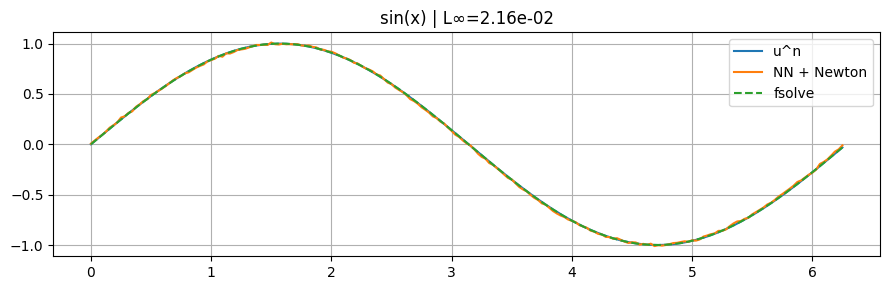

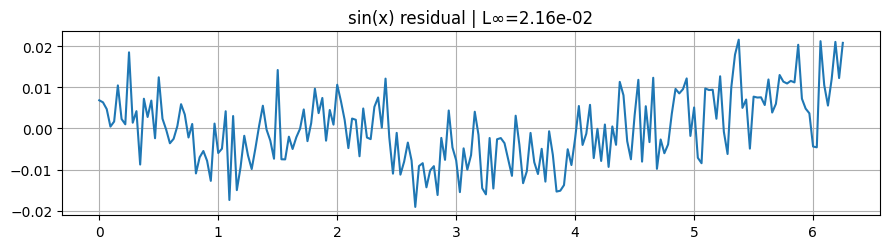

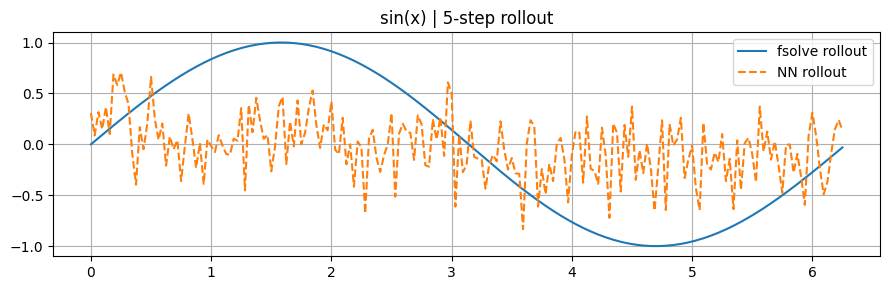


--- 0.5+0.25sin(x) ---
[test] 0.5+0.25sin(x) | L∞=2.261e-01 | Mean=7.585e-02
NN inference : 130.563 ms
fsolve solve : 21.682 ms
5-step rollout: 0.209 sec
Memory usage : 410.60 MB


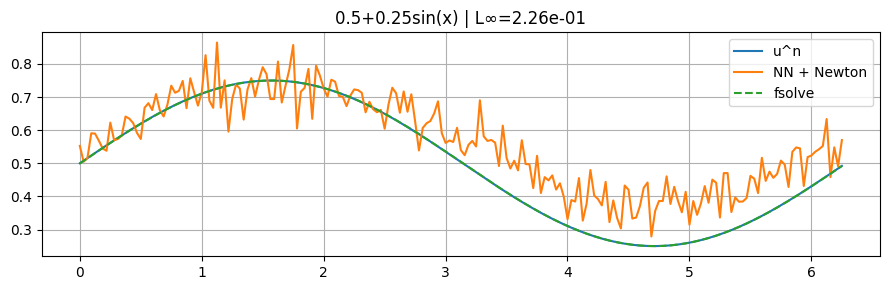

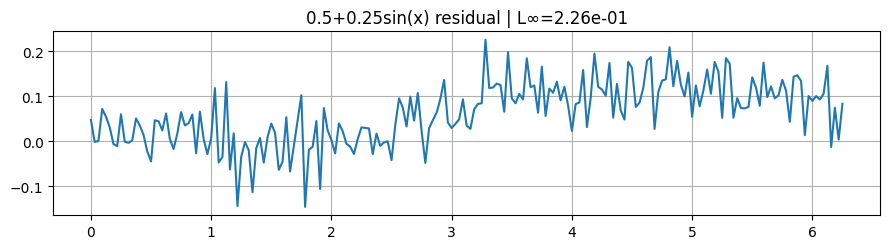

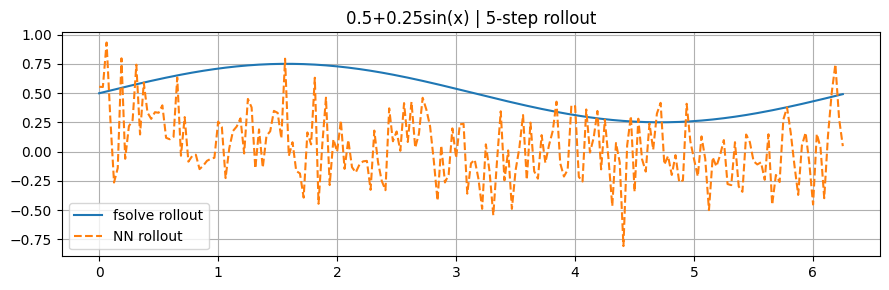


--- sin(sqrt(2)x) ---
[test] sin(sqrt(2)x) | L∞=9.755e-02 | Mean=3.015e-02
NN inference : 132.776 ms
fsolve solve : 23.197 ms
5-step rollout: 0.203 sec
Memory usage : 412.74 MB


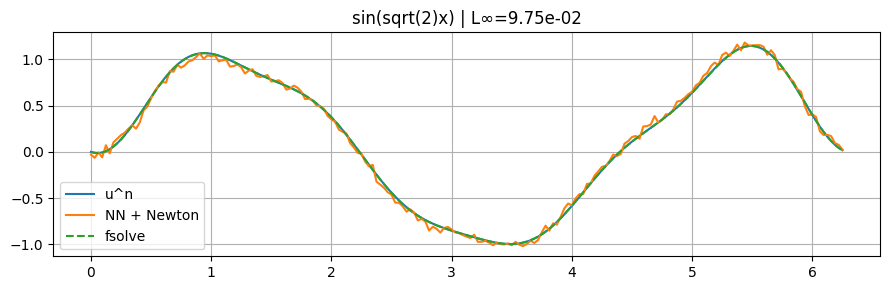

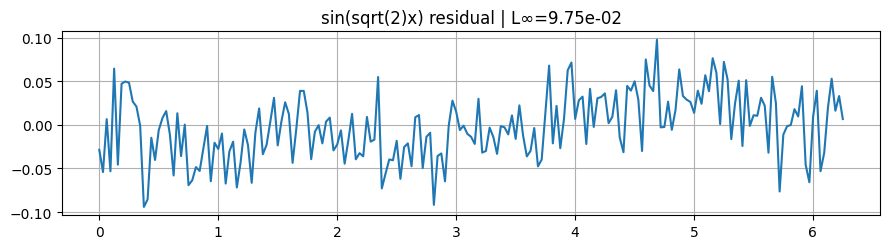

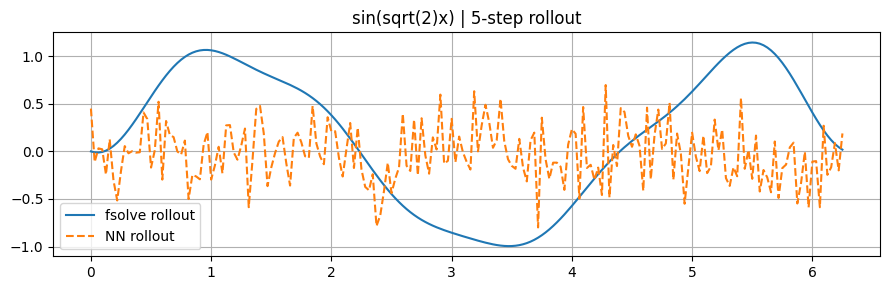


--- cos(sqrt(3)x) ---
[test] cos(sqrt(3)x) | L∞=2.442e-01 | Mean=6.262e-02
NN inference : 142.752 ms
fsolve solve : 22.006 ms
5-step rollout: 0.195 sec
Memory usage : 413.97 MB


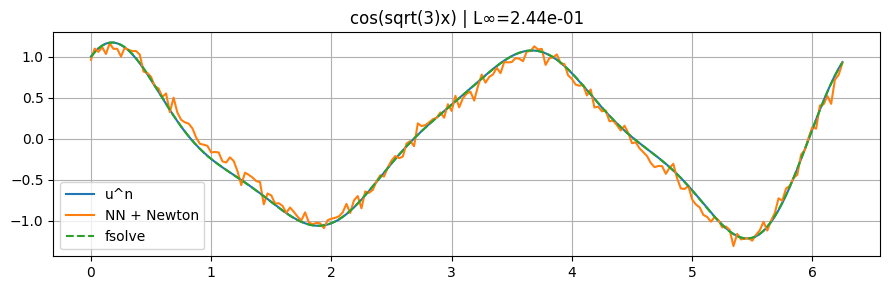

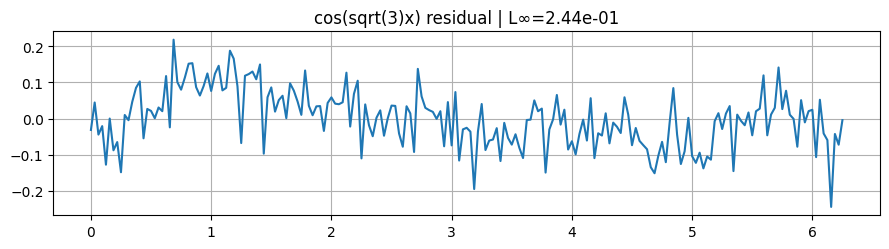

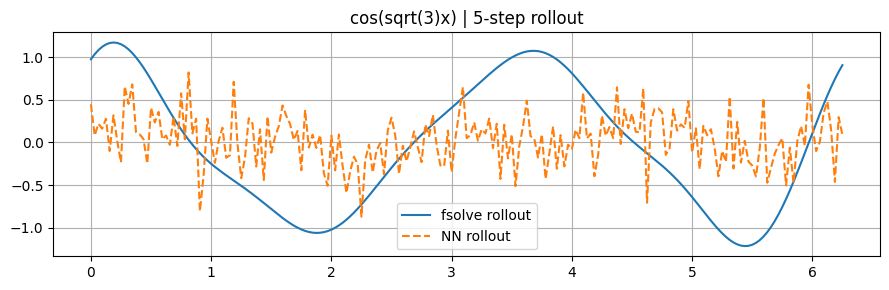


--- exp(-(x-pi)^2)*sin(sqrt(2)x) ---
[test] exp(-(x-pi)^2)*sin(sqrt(2)x) | L∞=2.910e-01 | Mean=9.114e-02
NN inference : 88.843 ms
fsolve solve : 13.902 ms
5-step rollout: 0.142 sec
Memory usage : 415.89 MB


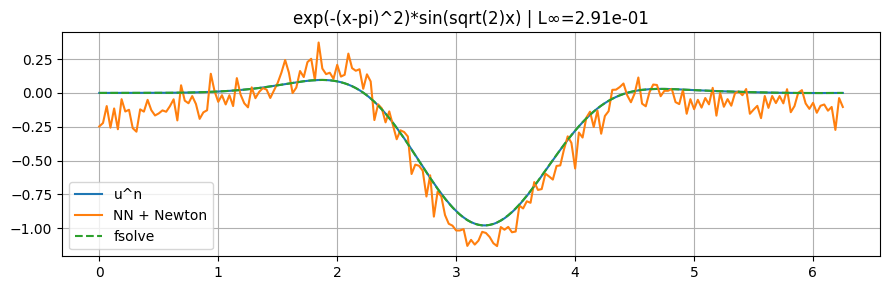

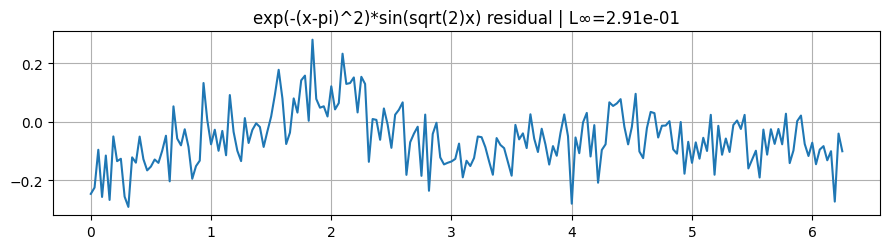

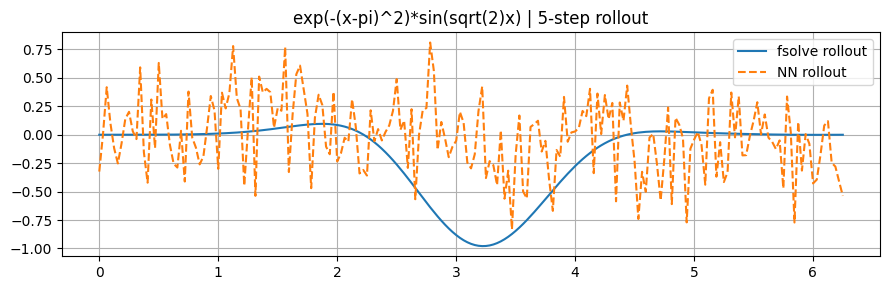


--- ((x-pi)^2)/(pi^2) ---
[test] ((x-pi)^2)/(pi^2) | L∞=2.272e-01 | Mean=5.865e-02
NN inference : 79.945 ms
fsolve solve : 16.963 ms
5-step rollout: 0.167 sec
Memory usage : 417.47 MB


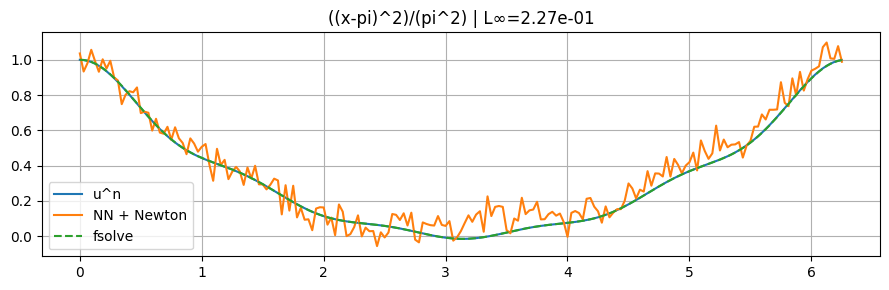

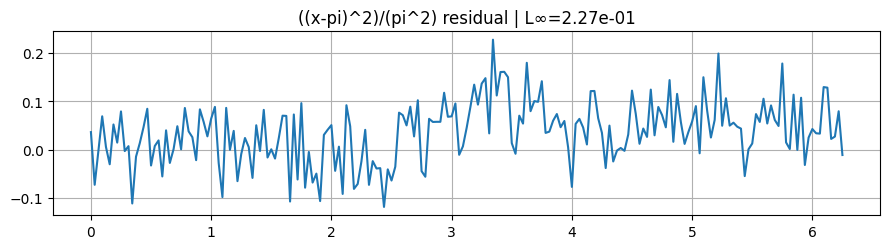

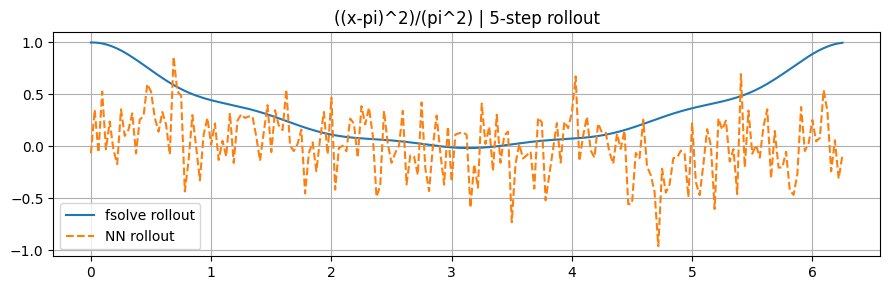


--- (pi^2-(x-pi)^2)/(pi^2) ---
[test] (pi^2-(x-pi)^2)/(pi^2) | L∞=2.178e-01 | Mean=7.324e-02
NN inference : 129.304 ms
fsolve solve : 13.939 ms
5-step rollout: 0.162 sec
Memory usage : 420.62 MB


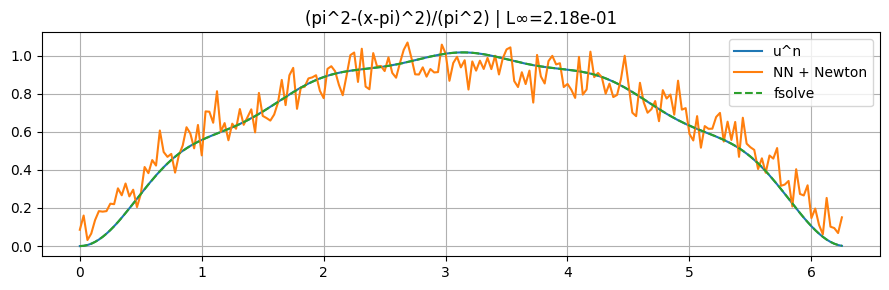

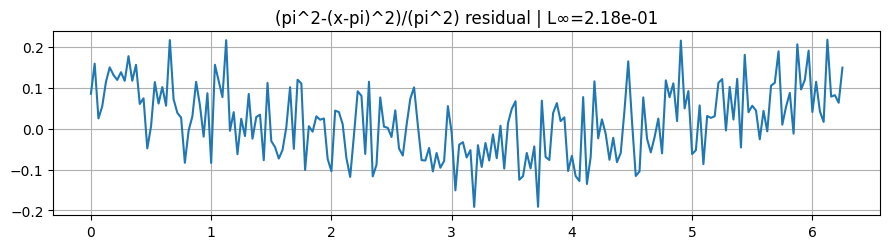

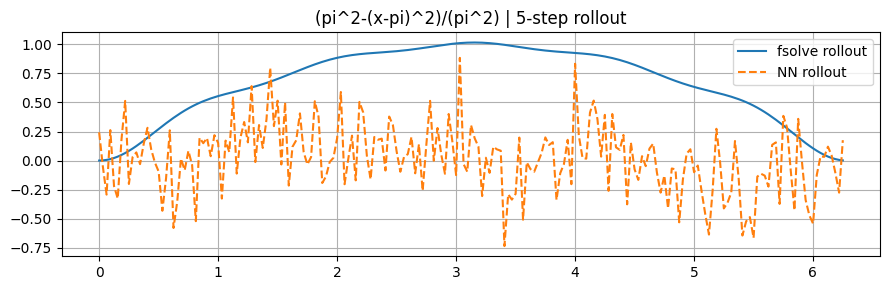


Saved summary CSV:
CaseD_Hybrid_Newton_0.005\testing_summary_caseD_0.005.csv

Plots saved in:
CaseD_Hybrid_Newton_0.005\plots

DONE.


In [14]:

import os
import csv
import time
import psutil

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from scipy.optimize import fsolve

tf.config.set_visible_devices([], 'GPU')

# paths
OUT_DIR = "CaseD_Hybrid_Newton_0.005"

PLOTS_DIR = os.path.join(
    OUT_DIR,
    "plots"
)

os.makedirs(PLOTS_DIR, exist_ok=True)

WEIGHTS_FILE = os.path.join(
    OUT_DIR,
    "caseD_best_0.005.weights.h5"
)

META_FILE = os.path.join(
    OUT_DIR,
    "caseD_meta_0.005.npz"
)

CSV_FILE = os.path.join(
    OUT_DIR,
    "testing_summary_caseD_0.005.csv"
)

# memory
process = psutil.Process(os.getpid())

def memory_mb():

    return process.memory_info().rss / 1024**2

# load meta
meta = np.load(
    META_FILE,
    allow_pickle=True
)

NX_FINE   = int(meta["NX_FINE"])

NX_COARSE = int(meta["NX_COARSE"])

DT = float(meta["DT"])

L  = float(meta["L"])

feat_mean = meta["feat_mean"]

feat_std  = meta["feat_std"]

# model config
HIDDEN_UNITS = 512

DEPTH = 5

SIREN_W0 = 15.0

NEWTON_ALPHA = 0.5

# grids
x_coarse = np.linspace(
    0,
    L,
    NX_COARSE,
    endpoint=False
)

x_fine = np.linspace(
    0,
    L,
    NX_FINE,
    endpoint=False
)

# differentiation matrix
def generate_D_matrix(Nx, L):

    k = 2*np.pi*1j*np.fft.fftfreq(
        Nx,
        d=L/Nx
    )

    I = np.eye(Nx)

    D_fft = np.fft.ifft(
        k[:, None] * np.fft.fft(I, axis=0),
        axis=0
    )

    return D_fft.real

D_np = generate_D_matrix(
    NX_FINE,
    L
)

# residual
def residual_np(y, u):

    return (
        y
        - u
        + 0.25*DT*(D_np @ (y**2))
    )

# fourier interpolation
def fourier_interpolate(u, Nc, Nf):

    U = np.fft.fftshift(
        np.fft.fft(u)
    )

    pad = Nf - Nc

    U = np.pad(
        U,
        (pad//2, pad-pad//2)
    )

    return (
        np.fft.ifft(
            np.fft.ifftshift(U)
        ) * Nf/Nc
    ).real

# fsolve
def compute_y1_fsolve(un):

    def F(y):

        return (
            y
            - un
            + 0.25*DT*(D_np @ (y**2))
        )

    def J(y):

        return (
            np.eye(len(un))
            + 0.5*DT*(D_np @ np.diag(y))
        )

    y = fsolve(
        F,
        un,
        fprime=J,
        xtol=1e-12
    )

    return y.astype(np.float64)

# newton corrector
def newton_correct(y, u):

    r = residual_np(y, u)

    J = (
        np.eye(NX_FINE)
        + 0.5 * DT * (
            D_np @ np.diag(y)
        )
    )

    try:

        delta = np.linalg.solve(J, r)

    except np.linalg.LinAlgError:

        delta = np.linalg.lstsq(
            J,
            r,
            rcond=None
        )[0]

    return y - NEWTON_ALPHA * delta

# Siren layer
class SineDense(tf.keras.layers.Layer):

    def __init__(
        self,
        units,
        w0=30.0,
        is_first=False,
        **kwargs
    ):

        super().__init__(
            dtype=tf.float64,
            **kwargs
        )

        self.units = int(units)

        self.w0 = float(w0)

        self.is_first = bool(is_first)

    def build(self, input_shape):

        in_dim = int(input_shape[-1])

        bound = (
            (1.0/in_dim)
            if self.is_first
            else
            (np.sqrt(6.0/in_dim)/self.w0)
        )

        self.W = self.add_weight(
            shape=(in_dim, self.units),
            initializer=tf.keras.initializers.RandomUniform(
                -bound,
                bound
            ),
            trainable=True,
            dtype=tf.float64
        )

        self.b = self.add_weight(
            shape=(self.units,),
            initializer="zeros",
            trainable=True,
            dtype=tf.float64
        )

    def call(self, x):

        return tf.sin(
            self.w0 * (
                tf.matmul(x, self.W) + self.b
            )
        )

# model
def build_model():

    input_dim = len(feat_mean)

    inputs = tf.keras.Input(
        shape=(input_dim,),
        dtype=tf.float64
    )

    h = inputs

    h = SineDense(
        HIDDEN_UNITS,
        w0=SIREN_W0,
        is_first=True
    )(h)

    for _ in range(DEPTH-1):

        h = SineDense(
            HIDDEN_UNITS,
            w0=SIREN_W0
        )(h)

    outputs = tf.keras.layers.Dense(
        NX_FINE,
        dtype=tf.float64
    )(h)

    return tf.keras.Model(
        inputs,
        outputs
    )

# model
model = build_model()

_ = model(
    tf.zeros(
        (1, len(feat_mean)),
        dtype=tf.float64
    )
)

model.load_weights(
    WEIGHTS_FILE
)

print("\nLoaded saved model.")

# safe filename
def safe_filename(name):

    return (
        name.replace("(", "")
            .replace(")", "")
            .replace("*", "")
            .replace("^", "")
            .replace("+", "")
            .replace("-", "")
            .replace("/", "_")
            .replace("\\", "_")
            .replace("=", "_")
            .replace(" ", "_")
    )

# features
def build_feat_single(u_f):

    mag = np.abs(
        np.fft.fft(u_f)
    )[:NX_FINE//2+1]

    mag = 0.2 * mag

    feats = np.concatenate([
        u_f,
        mag
    ])

    return (
        (feats - feat_mean)
        / feat_std
    )[None, :]

# rollout
def rollout_nn(u0, steps=5):

    u = u0.copy()

    traj = [u.copy()]

    for _ in range(steps):

        feat = build_feat_single(u)

        y = model(
            tf.constant(
                feat,
                dtype=tf.float64
            ),
            training=False
        ).numpy()[0]
          
        # newton correction
        y = (newton_correct(y, u))
        u = y.copy()

        traj.append(u.copy())

    return traj

# Test function
tests = [
    (
        "sin(x)",
        lambda x: np.sin(x)
    ),
    
    (
        "0.5+0.25sin(x)",
        lambda x: 0.5 + 0.25*np.sin(x)
    ), 
    # Irrational-frequency sin/cos
    (
        "sin(sqrt(2)x)",
        lambda x: np.sin(np.sqrt(2)*x)
    ),

    (
        "cos(sqrt(3)x)",
        lambda x: np.cos(np.sqrt(3)*x)
    ),   
    # Gaussian + irrational frequency
    (
        "exp(-(x-pi)^2)*sin(sqrt(2)x)",
        lambda x: np.exp(-(x - np.pi)**2)
                  * np.sin(np.sqrt(2)*x)
    ),      
    # Normalised polynomial family
    (
        "((x-pi)^2)/(pi^2)",
        lambda x: ((x - np.pi)**2) / (np.pi**2)
    ),

    (
        "(pi^2-(x-pi)^2)/(pi^2)",
        lambda x: (np.pi**2 - (x - np.pi)**2) / (np.pi**2)
    )
    
]

summary = []

# Testing
print("\nTEST & DIAGNOSTICS")

for name, fn in tests:

    print("\n---", name, "---")

    safe_name = safe_filename(name)

    # Initial condition
    uf = fourier_interpolate(
        fn(x_coarse),
        NX_COARSE,
        NX_FINE
    )

    # NN prediction
    feat = build_feat_single(uf)

    t0 = time.perf_counter()

    y_pred = model(
        tf.constant(
            feat,
            dtype=tf.float64
        ),
        training=False
    ).numpy()[0]

    # Newton corrector
    y_pred = newton_correct(
        y_pred,
        uf
    )

    t1 = time.perf_counter()

    nn_ms = 1000 * (t1 - t0)

    # Fsolve
    fs0 = time.perf_counter()

    y_fs = compute_y1_fsolve(uf)

    fs1 = time.perf_counter()

    fsolve_ms = 1000 * (fs1 - fs0)

    # Residual
    r = residual_np(
        y_pred,
        uf
    )

    Linf = float(
        np.max(np.abs(r))
    )

    Mean = float(
        np.mean(np.abs(r))
    )

    # Rollout
    steps = 5

    r0 = time.perf_counter()

    traj_nn = rollout_nn(
        uf,
        steps
    )

    r1 = time.perf_counter()

    rollout_sec = r1 - r0

    # Fsolve rollout
    traj_fs = [uf.copy()]

    tmp = uf.copy()

    for _ in range(steps):

        tmp = compute_y1_fsolve(tmp)

        traj_fs.append(tmp.copy())

    mem_now = memory_mb()

    print(
        f"[test] {name:12s} | "
        f"L∞={Linf:.3e} | "
        f"Mean={Mean:.3e}"
    )

    print(f"NN inference : {nn_ms:.3f} ms")

    print(f"fsolve solve : {fsolve_ms:.3f} ms")

    print(f"5-step rollout: {rollout_sec:.3f} sec")

    print(f"Memory usage : {mem_now:.2f} MB")

    xs = x_fine

    # Sol plot
    plt.figure(figsize=(9,3))

    plt.plot(
        xs,
        uf,
        label="u^n"
    )

    plt.plot(
        xs,
        y_pred,
        label="NN + Newton"
    )

    plt.plot(
        xs,
        y_fs,
        "--",
        label="fsolve"
    )

    plt.legend()

    plt.title(
        f"{name} | L∞={Linf:.2e}"
    )

    plt.grid(True)

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            PLOTS_DIR,
            f"{safe_name}_nn.png"
        ),
        dpi=150
    )

    plt.show()
    # Residual plot
    plt.figure(figsize=(9,2.6))

    plt.plot(xs, r)

    plt.title(
        f"{name} residual | L∞={Linf:.2e}"
    )

    plt.grid(True)

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            PLOTS_DIR,
            f"{safe_name}_res.png"
        ),
        dpi=150
    )

    plt.show()

    # Rollout
    plt.figure(figsize=(9,3))

    plt.plot(
        xs,
        traj_fs[-1],
        label="fsolve rollout"
    )

    plt.plot(
        xs,
        traj_nn[-1],
        "--",
        label="NN rollout"
    )

    plt.legend()

    plt.title(
        f"{name} | {steps}-step rollout"
    )

    plt.grid(True)

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            PLOTS_DIR,
            f"{safe_name}_rollout.png"
        ),
        dpi=150
    )

    plt.show()

    summary.append([

        name,

        Linf,

        Mean,

        nn_ms,

        fsolve_ms,

        rollout_sec,

        mem_now
    ])

# SAVE CSV
with open(CSV_FILE, "w", newline="") as f:

    writer = csv.writer(f)

    writer.writerow([

        "Function",

        "Linf",

        "MeanResidual",

        "NN_Inference_ms",

        "fsolve_ms",

        "Rollout_sec",

        "Memory_MB"
    ])

    writer.writerows(summary)

print("\nSaved summary CSV:")

print(CSV_FILE)

print("\nPlots saved in:")

print(PLOTS_DIR)

print("\nDONE.")